# **Project - Online Retail Capstone Project**

#**Project Summary**

The goal of this machine learning project was to perform customer segmentation for an online retail business. Customer segmentation involves dividing customers into distinct groups based on their behaviors, preferences, or common characteristics. This allows businesses to better understand their customers and design targeted marketing strategies, ultimately improving customer satisfaction and driving profitability.

After initial data exploration and cleaning, we performed Exploratory Data Analysis (EDA) to uncover patterns and relationships among key features. We then conducted RFM (Recency, Frequency, Monetary) analysis to categorize customers based on their purchasing behavior. This helped us identify high-value segments such as Platinum and Gold customers, who contribute significantly to revenue. At the same time, it highlighted Silver and Bronze customers, giving the business a chance to re-engage them through special offers and promotions.

To cluster the customers, we applied several unsupervised machine learning algorithms, including KMeans Clustering, DBSCAN, and Agglomerative Hierarchical Clustering. To determine the optimal number of clusters for KMeans, we used the Elbow Method as well as Elbow Visualizer from the Yellowbrick library. We also evaluated cluster quality using the Silhouette Score and visualized the results with Silhouette Plots. For Agglomerative Clustering, we used a Dendrogram to help determine the ideal number of clusters.

Overall, this project provided valuable insights into customer behavior and demonstrated how machine learning can help a retail business segment its customer base effectively for more personalized engagement.

#**Problem Description**

In this project, our objective was to identify key customer segments using a transactional dataset from a UK-based, non-store online retail company. The dataset includes all transactions that took place between December 1, 2010 and December 9, 2011. The company primarily sells unique, all-occasion gift items, and its customer base includes both individual buyers and wholesale clients.

By analyzing this data, we aimed to uncover meaningful customer patterns and group similar customers together. These insights can help the business better understand its clientele, personalize marketing efforts, and improve overall customer engagement and retention.



# **1. Know Your Data**

## Importing Libraries

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn import preprocessing

# setting max display column limit to 30
pd.set_option("display.max_columns", 30)

import warnings
warnings.filterwarnings('ignore')


## Loading Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import the data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Copy of Online Retail.xlsx - Online Retail.csv')

## Dataset First View

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


## Dataset Rows & Columns count

In [ ]:
df.shape

(541909, 8)

## Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# **2. Understanding the Variables**

## Variables Description

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# **3. Data Wrangling:**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


If InvoiceNo starts with C means it's a cancellation. We need to drop this entries.
There are null values in CustomerID and Description.

## Checking For Null Values

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


Text(0.5, 1.0, ' Visualizing Missing Values')

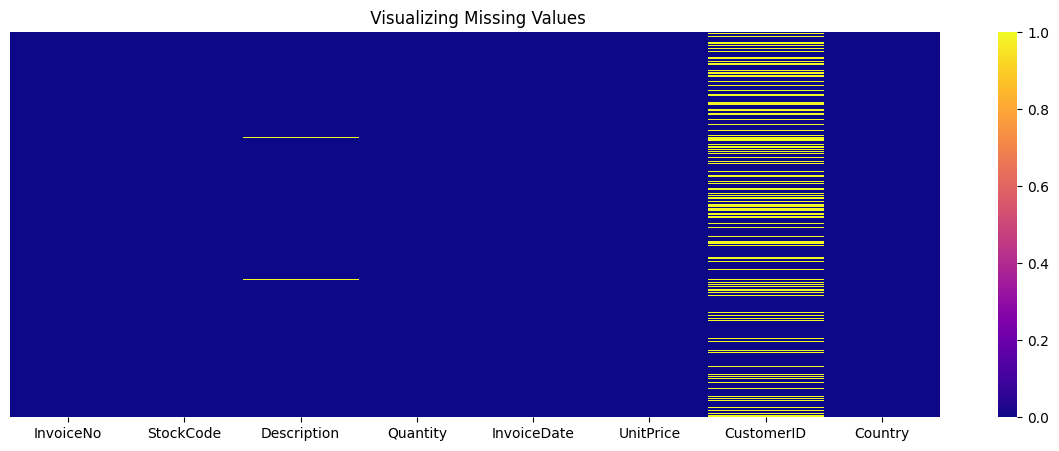

In [ ]:
 #Visulaizing null values using the heatmap.

plt.figure(figsize=(15,5))
sns.heatmap(df.isnull(),cmap='plasma',annot=False,yticklabels=False)
plt.title(" Visualizing Missing Values")

There are Null values in 'CustomerID' and 'Description' columns.
CustomerID is our identification feature so if its missing means other features wont helpful to us in analysis
So, we will have to drop these missing datapoints

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(406829, 8)

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570
std,248.693370,69.315162,1713.600303
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,38970.000000,18287.000000


Here we can see that the min value for Quantity column is negative.
UnitPrice has 0 as min value
We need to Explore these columns

In [ ]:
df[df['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/11 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/11 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/11 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/11 11:58,1.25,17315.0,United Kingdom


In [ ]:
# changing the datatype to str
df['InvoiceNo'] = df['InvoiceNo'].astype('str')

df=df[~df['InvoiceNo'].str.contains('C')]

In [ ]:
len(df[df['UnitPrice']==0])

40

In [ ]:
df=df[df['UnitPrice']>0]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,15294.423453
std,179.331775,22.097877,1713.141560
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [ ]:
df.shape

(397884, 8)

# **Feature Engineering & Data Pre-processing**

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%y %H:%M")

In [ ]:
df["year"] = df["InvoiceDate"].apply(lambda x: x.year)
df["month_num"] = df["InvoiceDate"].apply(lambda x: x.month)
df["day_num"] = df["InvoiceDate"].apply(lambda x: x.day)
df["hour"] = df["InvoiceDate"].apply(lambda x: x.hour)
df["minute"] = df["InvoiceDate"].apply(lambda x: x.minute)

In [ ]:
# extracting month from the Invoice date

df['Month']=df['InvoiceDate'].dt.month_name()

In [ ]:
# extracting day from the Invoice date

df['Day']=df['InvoiceDate'].dt.day_name()

In [ ]:
# creating a new calculated column for the amount spend on each sale.

df['TotalAmount']=df['Quantity']*df['UnitPrice']

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year,month_num,day_num,hour,minute,Month,Day,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,26,December,Wednesday,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,December,Wednesday,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,26,December,Wednesday,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,December,Wednesday,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,December,Wednesday,20.34


# **4. Exploratory Data Analysis**

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'year', 'month_num', 'day_num',
       'hour', 'minute', 'Month', 'Day', 'TotalAmount'],
      dtype='object')

#**Chart 1**

In [ ]:
# Top 10 products sold

top_10_product=df['Description'].value_counts().reset_index().rename(columns={'index':'Product_name','Description':'Count'}).head(10)
top_10_product

,Count,count
0,WHITE HANGING HEART T-LIGHT HOLDER,2028
1,REGENCY CAKESTAND 3 TIER,1723
2,JUMBO BAG RED RETROSPOT,1618
3,ASSORTED COLOUR BIRD ORNAMENT,1408
4,PARTY BUNTING,1396
5,LUNCH BAG RED RETROSPOT,1316
6,SET OF 3 CAKE TINS PANTRY DESIGN,1159
7,LUNCH BAG BLACK SKULL.,1105
8,POSTAGE,1099
9,PACK OF 72 RETROSPOT CAKE CASES,1068


## ***Top 10 products Sold***

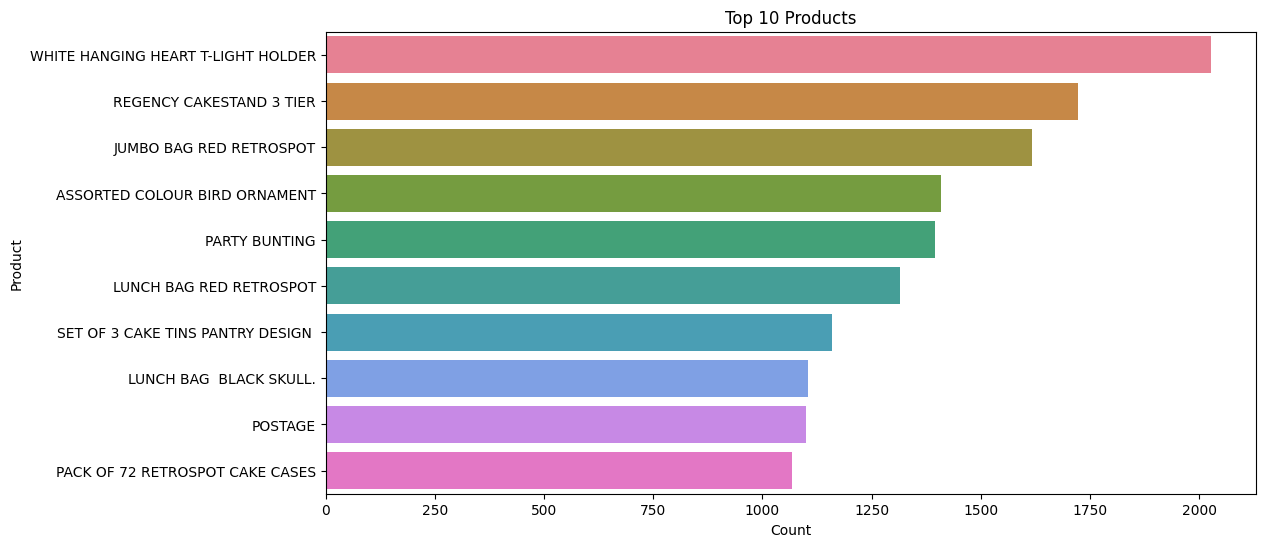

In [ ]:
# top 10 product in terms of description
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_product['count'],
    y=top_10_product['Count'],
    palette=sns.color_palette("husl", len(top_10_product))
)
plt.title('Top 10 Products')
plt.xlabel('Count')
plt.ylabel('Product')
plt.show()


#**Chart 2**

## ***Bottom 10 products sold***

In [ ]:
bottom_10_product=df['Description'].value_counts().reset_index().rename(columns={'index':'Product_name','Description':'Count'}).tail(10)
bottom_10_product

,Count,count
3867,SILVER/CRYSTAL DROP EARRINGS W LEAF,1
3868,GREEN DROP EARRINGS W BEAD CLUSTER,1
3869,AMBER GLASS/SHELL/PEARL NECKLACE,1
3870,5 STRAND GLASS NECKLACE AMETHYST,1
3871,RUBY GLASS CLUSTER NECKLACE,1
3872,CLASSIC DIAMANTE NECKLACE JET,1
3873,DIAMANTE NECKLACE BLACK,1
3874,ANT SILVER TURQUOISE BOUDICCA RING,1
3875,PINK CHERRY BLOSSOM CUP & SAUCER,1
3876,BLUE PADDED SOFT MOBILE,1


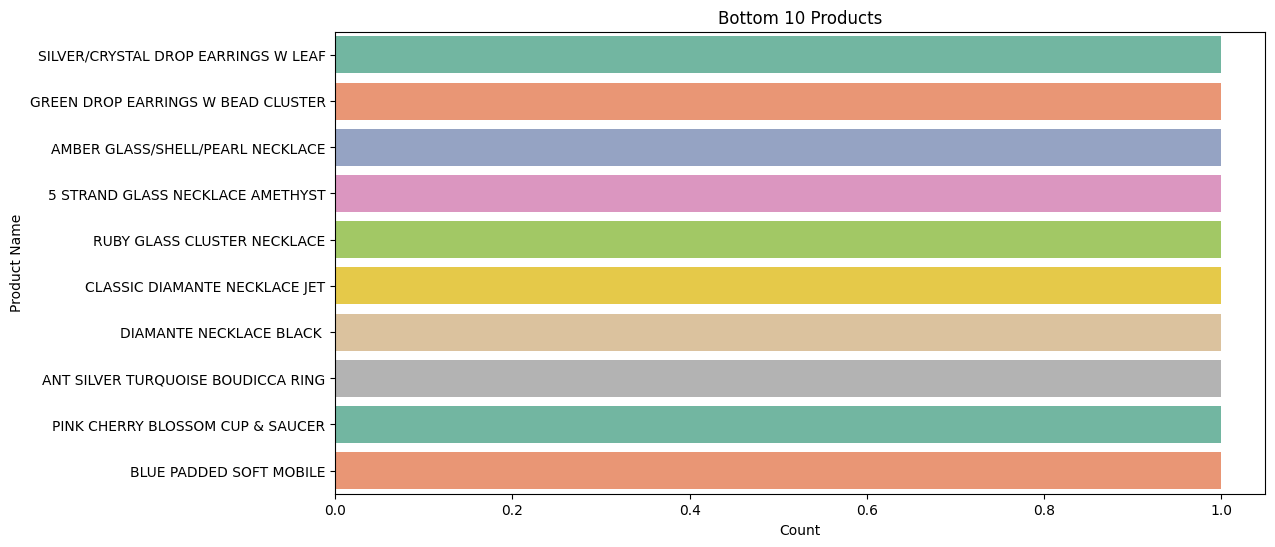

In [ ]:
# bottom 10 product in terms of description
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    x=bottom_10_product['count'],
    y=bottom_10_product['Count'],
    palette=sns.color_palette("Set2", len(bottom_10_product))
)
plt.title('Bottom 10 Products')
plt.xlabel('Count')
plt.ylabel('Product Name')
plt.show()


#**Chart 3**

## ***Top 10 items in terms of StockCode.***

In [ ]:
top_10_StockCodes=df['StockCode'].value_counts().reset_index().rename(columns={'index':'StockCode','StockCode':'Count'}).head(10)
top_10_StockCodes

,Count,count
0,85123A,2035
1,22423,1723
2,85099B,1618
3,84879,1408
4,47566,1396
5,20725,1317
6,22720,1159
7,20727,1105
8,POST,1099
9,23203,1098


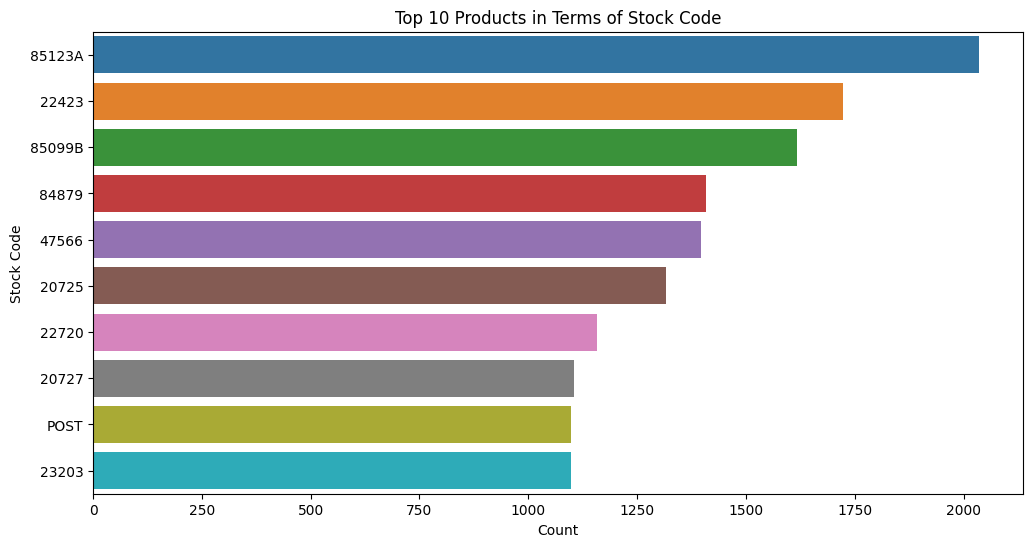

In [ ]:
# top 10 product in terms of StockCode
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_StockCodes['count'],
    y=top_10_StockCodes['Count'],
    palette=sns.color_palette("tab10", len(top_10_StockCodes))
)
plt.title('Top 10 Products in Terms of Stock Code')
plt.xlabel('Count')
plt.ylabel('Stock Code')
plt.show()


#**Chart 4**

In [ ]:
top_10_customers=df['CustomerID'].value_counts().reset_index().rename(columns={'index':'CustomerID','CustomerID':'Products_purchasing_Count'}).head(10)
top_10_customers

,Products_purchasing_Count,count
0,17841.0,7847
1,14911.0,5675
2,14096.0,5111
3,12748.0,4595
4,14606.0,2700
5,15311.0,2379
6,14646.0,2076
7,13089.0,1818
8,13263.0,1677
9,14298.0,1637


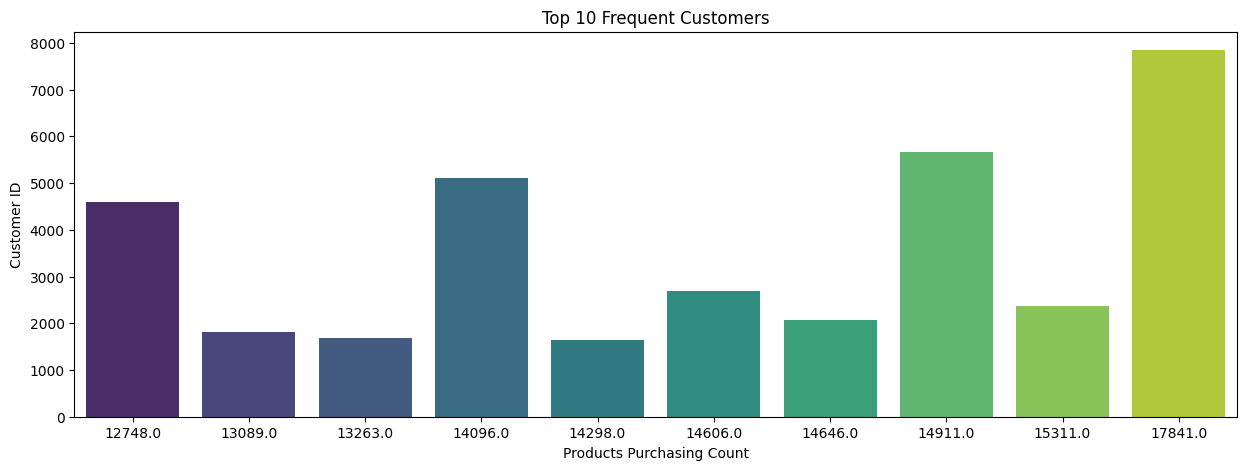

In [ ]:
# Top 10 frequent Customers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))
sns.barplot(
    x=top_10_customers['Products_purchasing_Count'],
    y=top_10_customers['count'].head(10),
    palette=sns.color_palette("viridis", len(top_10_customers.head(10)))
)
plt.title('Top 10 Frequent Customers')
plt.xlabel('Products Purchasing Count')
plt.ylabel('Customer ID')
plt.show()


#**Chart 5**

## **Top 5 countries where max sale happens**

In [ ]:
top_countries=df['Country'].value_counts().reset_index().rename(columns={'index':'Country','Country':'Customer_count'})
top_countries

,Customer_count,count
0,United Kingdom,354321
1,Germany,9040
2,France,8341
3,EIRE,7236
4,Spain,2484
5,Netherlands,2359
6,Belgium,2031
7,Switzerland,1841
8,Portugal,1462
9,Australia,1182


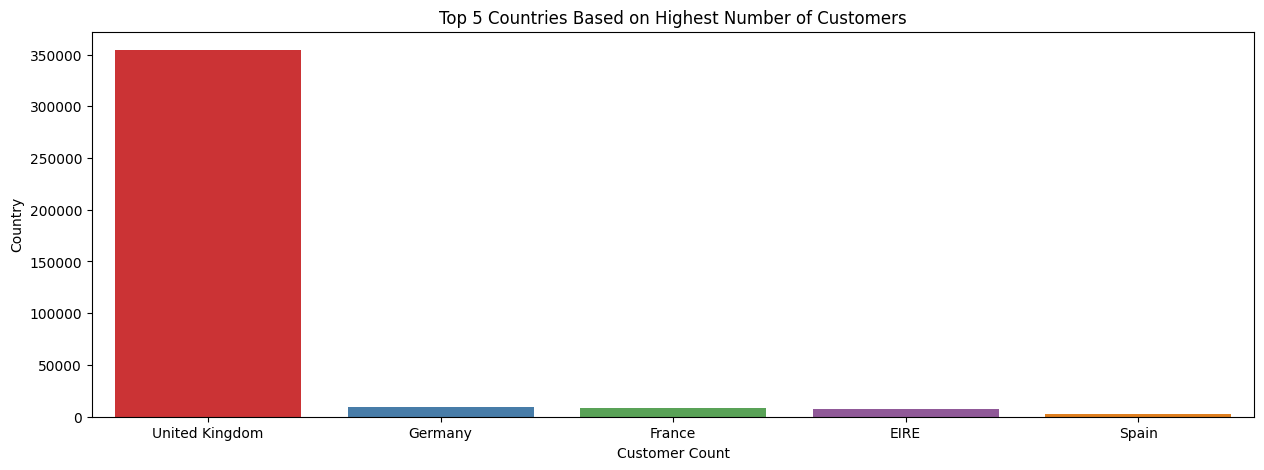

In [ ]:
# top 5 countries where max sale happens.
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
sns.barplot(
    x=top_countries['Customer_count'].head(5),
    y=top_countries['count'].head(5),
    palette=sns.color_palette("Set1", 5)
)
plt.title('Top 5 Countries Based on Highest Number of Customers')
plt.xlabel('Customer Count')
plt.ylabel('Country')
plt.show()


#**Chart 6**

#**Top 5 countries where min sell happens**

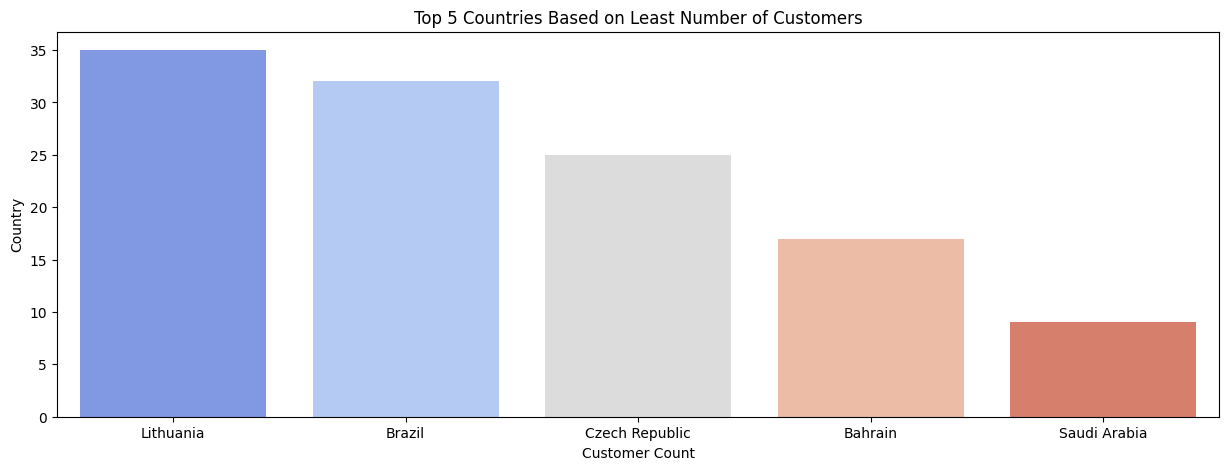

In [ ]:
# top 5 countries where min sell happens.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))
sns.barplot(
    x=top_countries['Customer_count'].tail(5),
    y=top_countries['count'].tail(5),
    palette=sns.color_palette("coolwarm", 5)
)
plt.title('Top 5 Countries Based on Least Number of Customers')
plt.xlabel('Customer Count')
plt.ylabel('Country')
plt.show()


#**Chart 7**

#**Sales count in different months**

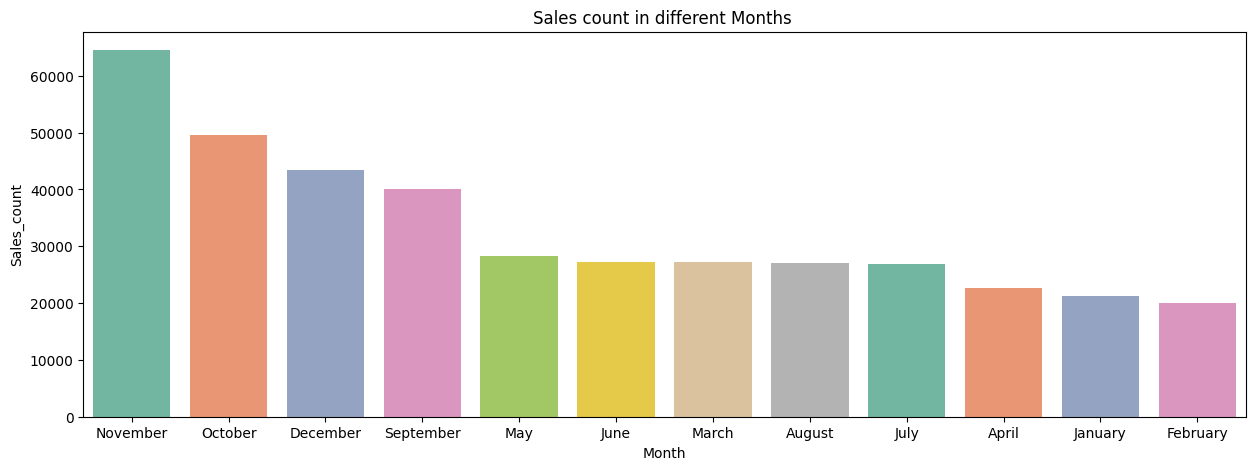

In [ ]:
# Sales count in different months.
sales_in_month = df['Month'].value_counts().reset_index().rename(columns={'index': 'Month', 'count': 'Sales_count'})
plt.figure(figsize=(15,5))
sns.barplot(x=sales_in_month['Month'], y=sales_in_month['Sales_count'], palette=sns.color_palette("Set2", len(sales_in_month)))
plt.title('Sales count in different Months ')
plt.show()


#**Chart 8**

##**Sales count on different days**

In [ ]:
sales_on_day_basis=df['Day'].value_counts().reset_index().rename(columns={'index':'Day',"Day":'Sale_count'})
sales_on_day_basis

,Sale_count,count
0,Thursday,80035
1,Wednesday,68885
2,Tuesday,66473
3,Monday,64893
4,Sunday,62773
5,Friday,54825


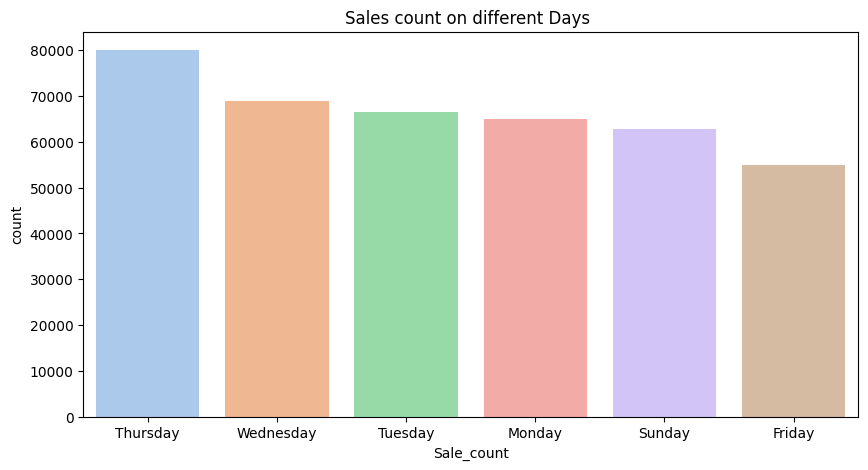

In [ ]:
# Sales count on different days.
plt.figure(figsize=(10,5))
sns.barplot(
    x=sales_on_day_basis['Sale_count'],
    y=sales_on_day_basis['count'],
    palette=sns.color_palette("pastel", len(sales_on_day_basis))
)
plt.title('Sales count on different Days ')
plt.show()


#**Chart 9**

##**Sales Count in different day timings**

In [ ]:
df['hour'].unique()

array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17,  7, 18, 19, 20,  6])

In [ ]:
def time(time):
  if (time==6 or time==7 or time==8 or time==9 or time==10 or time==11) :
    return'Morning'
  elif (time==12 or time==13 or time==14 or time==15 or time==16 or time==17):
    return 'Afternoon'
  else:
    return 'Evening'


In [ ]:
df['Day_time_type']=df['hour'].apply(time)

In [ ]:
sales_timing=df['Day_time_type'].value_counts().reset_index().rename(columns={'index':'Day_time_type','Day_time_type':'Sales_count'})
sales_timing

,Sales_count,count
0,Afternoon,272738
1,Morning,118095
2,Evening,7051


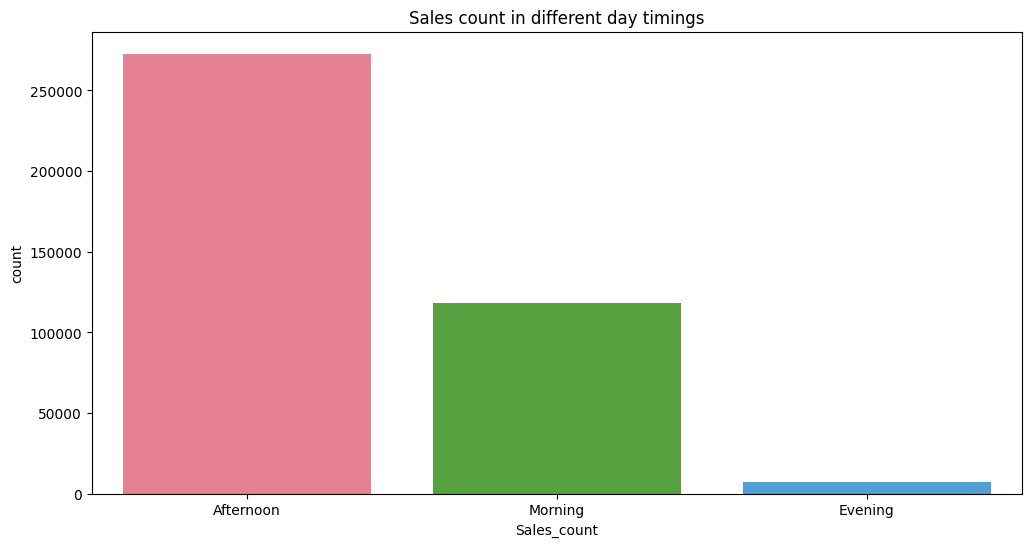

In [ ]:
# Sales count on different days.
plt.figure(figsize=(12,6))
sns.barplot(
    x=sales_timing['Sales_count'],
    y=sales_timing['count'],
    palette=sns.color_palette("husl", len(sales_timing))
)
plt.title('Sales count in different day timings')
plt.show()


#**Chart 10**

##**Average Amount Spent by each customer**

In [ ]:
avg_amount=df.groupby('CustomerID')['TotalAmount'].mean().reset_index().rename(columns={'TotalAmount':'Avg_amount_per_customer'}).sort_values('Avg_amount_per_customer',ascending=False)

In [ ]:
avg_amount

,CustomerID,Avg_amount_per_customer
0,12346.0,77183.600000
3008,16446.0,56157.500000
2011,15098.0,13305.500000
2502,15749.0,4453.430000
2087,15195.0,3861.000000
...,...,...
3590,17254.0,2.432500
697,13271.0,2.264375
990,13684.0,2.241000
3995,17816.0,2.150588


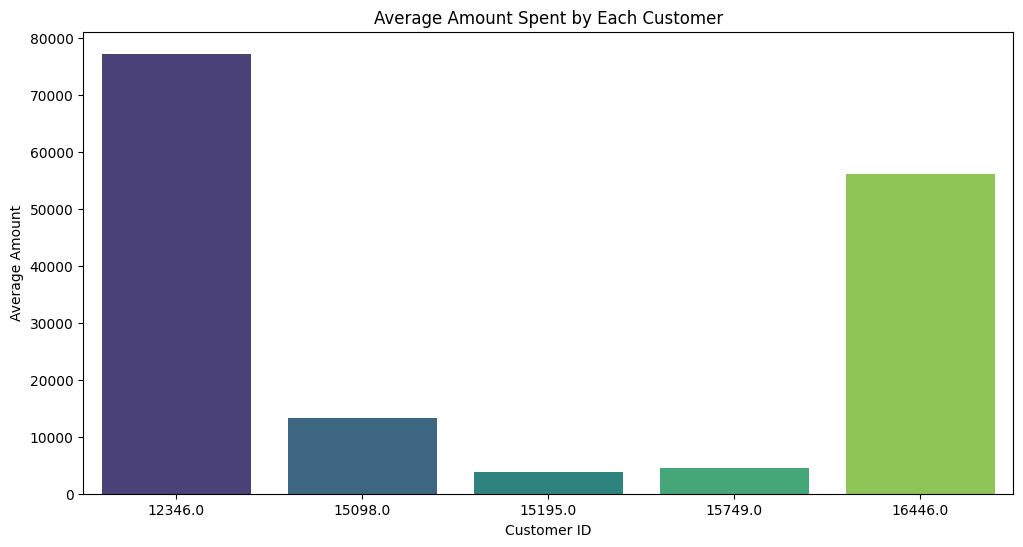

In [ ]:
# Sales count on different days.
plt.figure(figsize=(12,6))
sns.barplot(
    x=avg_amount['CustomerID'].head(5),
    y=avg_amount['Avg_amount_per_customer'].head(15),
    palette=sns.color_palette("viridis", 5)
)
plt.title('Average Amount Spent by Each Customer')
plt.xlabel('Customer ID')
plt.ylabel('Average Amount')
plt.show()


#**Chart 11**

##**Correlation Heatmap**

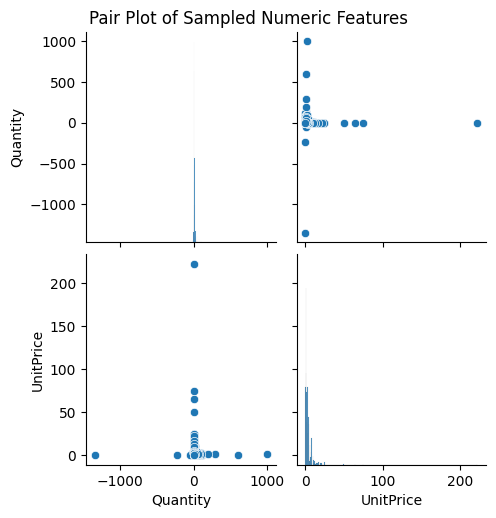

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Copy of Online Retail.xlsx - Online Retail.csv")

# Select relevant numeric columns
cols = ['Quantity', 'UnitPrice']  # You can add more numeric columns
df_subset = df[cols]

# Drop missing values safely
df_subset = df_subset.dropna()

# Sample data for plotting (to avoid long computation)
df_sample = df_subset.sample(n=1000, random_state=42)

# Create pairplot
sns.pairplot(df_sample)
plt.suptitle("Pair Plot of Sampled Numeric Features", y=1.02)
plt.show()


# **RFM Model Analysis:**

In [ ]:
rfm_dataframe=df.copy()

In [ ]:
rfm_dataframe.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [ ]:
#Recency = Latest Date - Last Inovice Data, Frequency = count of invoice no. of transaction(s), Monetary = Sum of Total
#Amount for each customer
import datetime as dt

#Set Latest date 2011-12-10 as last invoice date was 2011-12-09. This is to calculate the number of days from recent purchase
Latest_Date = dt.datetime(2011,12,10)

rfm_dataframe=df.copy()

# Convert InvoiceDate to datetime objects with a specified format
rfm_dataframe["InvoiceDate"] = pd.to_datetime(rfm_dataframe["InvoiceDate"], format="%m/%d/%y %H:%M")

# Ensure 'TotalAmount' is available
rfm_dataframe['TotalAmount'] = rfm_dataframe['Quantity'] * rfm_dataframe['UnitPrice']

#Create RFM Modelling scores for each customer
rfm_dataframe = rfm_dataframe.groupby('CustomerID').agg({'InvoiceDate': lambda x: (Latest_Date - x.max()).days, 'InvoiceNo': lambda x: len(x), 'TotalAmount': lambda x: x.sum()})

#Convert Invoice Date into type int (now Recency column)
rfm_dataframe['InvoiceDate'] = rfm_dataframe['InvoiceDate'].astype(int)

#Rename column names to Recency, Frequency and Monetary
rfm_dataframe.rename(columns={'InvoiceDate': 'Recency',
                         'InvoiceNo': 'Frequency',
                         'TotalAmount': 'Monetary'}, inplace=True)

rfm_dataframe.reset_index().head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,2,0.00
1,12347.0,2,182,4310.00
2,12348.0,75,31,1797.24
3,12349.0,18,73,1757.55
4,12350.0,310,17,334.40


In [ ]:
# Descriptive Stats= Recency
rfm_dataframe.Recency.describe()

,Recency
count,4372.000000
mean,91.581199
std,100.772139
min,0.000000
25%,16.000000
50%,50.000000
75%,143.000000
max,373.000000


Text(0.5, 1.0, 'Distribution of Recency')

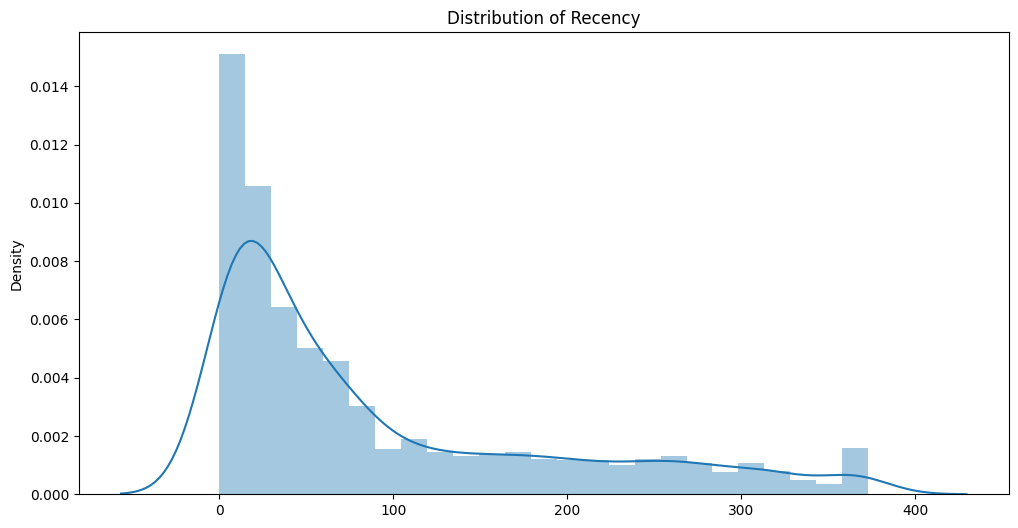

In [ ]:
plt.figure(figsize=(12,6))
sns.distplot(x=rfm_dataframe['Recency'])
plt.title('Distribution of Recency')

In [ ]:
# Descriptive Stats= Frequency
rfm_dataframe['Frequency'].describe()

,Frequency
count,4372.000000
mean,93.053294
std,232.471608
min,1.000000
25%,17.000000
50%,42.000000
75%,102.000000
max,7983.000000


Text(0.5, 1.0, 'Distribution of Frequency')

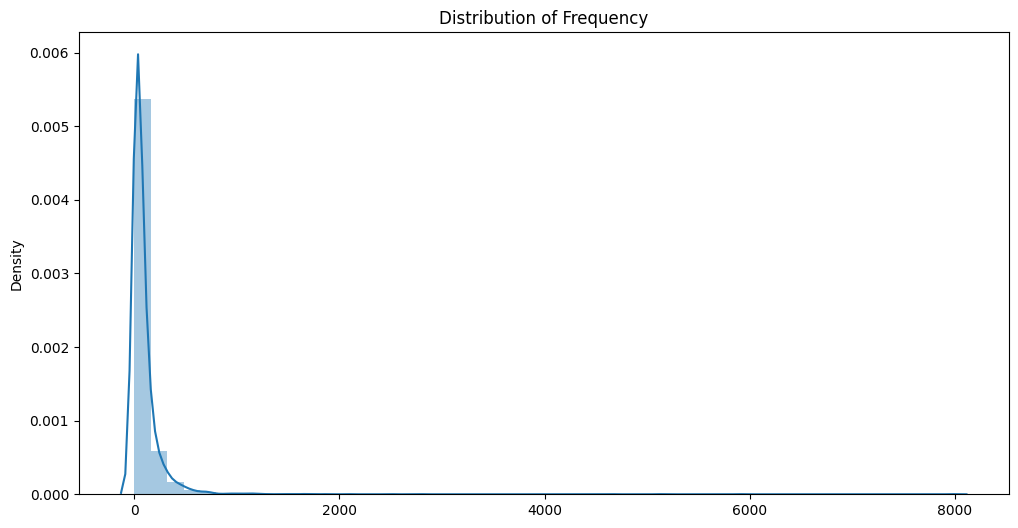

In [ ]:
plt.figure(figsize=(12,6))
sns.distplot(x=rfm_dataframe['Frequency'])
plt.title('Distribution of Frequency')

In [ ]:
# Descriptive Stats= Monetary
rfm_dataframe['Monetary'].describe()

,Monetary
count,4372.000000
mean,1898.459701
std,8219.345141
min,-4287.630000
25%,293.362500
50%,648.075000
75%,1611.725000
max,279489.020000


Text(0.5, 1.0, 'Distribution of Monetary')

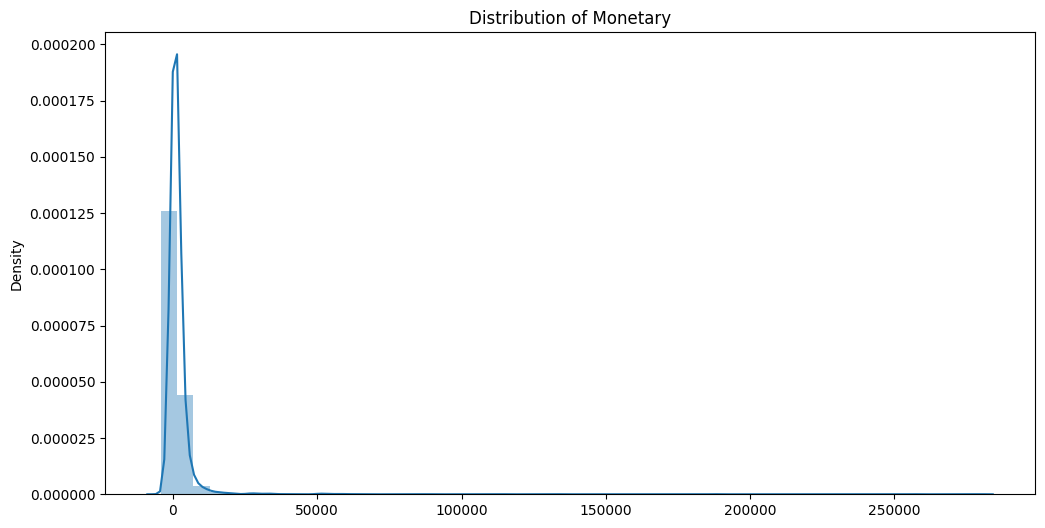

In [ ]:
plt.figure(figsize=(12,6))
sns.distplot(x=rfm_dataframe['Monetary'])
plt.title('Distribution of Monetary')

##**5. Feature Manipulation & Selection**

In [ ]:
import pandas as pd
import numpy as np

# Load dataset (update path if needed)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Copy of Online Retail.xlsx - Online Retail.csv', encoding='ISO-8859-1')

# Preview and check for nulls
print(df.head())
print(df.isnull().sum())

# Drop rows with missing values
df.dropna(inplace=True)


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

    InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/10 8:26       2.55     17850.0  United Kingdom  
1  12/1/10 8:26       3.39     17850.0  United Kingdom  
2  12/1/10 8:26       2.75     17850.0  United Kingdom  
3  12/1/10 8:26       3.39     17850.0  United Kingdom  
4  12/1/10 8:26       3.39     17850.0  United Kingdom  
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


#**Feature Manipulation**

In [ ]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract date-related features
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceHour'] = df['InvoiceDate'].dt.hour
df['InvoiceWeekday'] = df['InvoiceDate'].dt.weekday


In [ ]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['CustomerID'] = le.fit_transform(df['CustomerID'])


In [ ]:
df = pd.get_dummies(df, columns=['Country', 'StockCode'], drop_first=True)


In [ ]:
# Simulate target: whether TotalAmount is above median
df['Email_Status'] = (df['TotalAmount'] > df['TotalAmount'].median()).astype(int)


#**Feature Selection**

In [ ]:
import pandas as pd
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
import numpy as np # Import numpy

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Copy of Online Retail.xlsx - Online Retail.csv')

# Drop rows with missing values
df.dropna(subset=['Quantity', 'UnitPrice', 'CustomerID', 'Country'], inplace=True)

# Create a new target column: HighQuantity (1 if Quantity > median, else 0)
median_quantity = df['Quantity'].median()
df['HighQuantity'] = (df['Quantity'] > median_quantity).astype(int)

# Drop unneeded columns and 'StockCode' for chi-square test
X = df.drop(columns=['InvoiceNo', 'Description', 'InvoiceDate', 'Quantity', 'HighQuantity', 'StockCode'])

# Encode categorical column 'Country'
le = LabelEncoder()
X['Country'] = le.fit_transform(X['Country'])

# Target variable
y = df['HighQuantity']

# Ensure all values are non-negative (chi2 requirement) - apply only to numeric columns
numeric_cols = X.select_dtypes(include=np.number).columns
X[numeric_cols] = X[numeric_cols].clip(lower=0)

# Chi-square test
chi2_scores, p_values = chi2(X, y)

# Create DataFrame of results
chi2_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi2_scores,
    'p-value': p_values
}).sort_values(by='Chi2 Score', ascending=False)

print(chi2_df)

      Feature    Chi2 Score  p-value
1  CustomerID  1.612874e+06      0.0
0   UnitPrice  2.931317e+05      0.0
2     Country  1.368926e+04      0.0


/tmp/ipython-input-8-1272953808.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


        Feature  Mutual Information
6    InvoiceDay            0.566423
2    CustomerID            0.532815
3       Country            0.292034
4   InvoiceYear            0.252296
5  InvoiceMonth            0.205165
1     UnitPrice            0.023577
0      Quantity            0.019983
7   InvoiceHour            0.013601


/tmp/ipython-input-8-1272953808.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x='Mutual Information', y='Feature', palette='viridis')


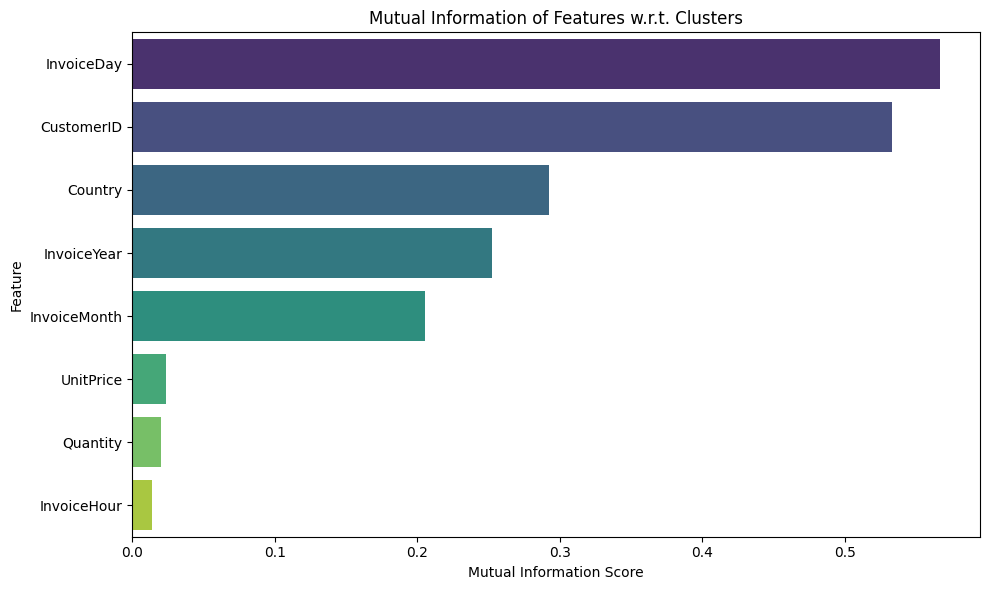

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Copy of Online Retail.xlsx - Online Retail.csv')

# Select relevant columns
cols = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
        'UnitPrice', 'CustomerID', 'Country']
df = df[cols]

# Drop rows with missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Feature Engineering
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

# Drop high-cardinality or text-heavy columns
df.drop(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate'], axis=1, inplace=True)

# Encode categorical variables
le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])
df['CustomerID'] = df['CustomerID'].astype(int)

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

# KMeans Clustering to get cluster labels (pseudo target)
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)

# Calculate Mutual Information between each feature and the cluster labels
mi_scores = mutual_info_classif(scaled_features, cluster_labels, discrete_features='auto')

# Convert to DataFrame for better readability
feature_names = df.columns
mi_df = pd.DataFrame({'Feature': feature_names, 'Mutual Information': mi_scores})
mi_df.sort_values(by='Mutual Information', ascending=False, inplace=True)

# Show MI scores
print(mi_df)

# Visualize
plt.figure(figsize=(10,6))
sns.barplot(data=mi_df, x='Mutual Information', y='Feature', palette='viridis')
plt.title('Mutual Information of Features w.r.t. Clusters')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


#**6. Feature Engineering and Data Pre Processing**

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Copy of Online Retail.xlsx - Online Retail.csv', encoding='ISO-8859-1')
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.0600

#**Handling Missing Values**

In [ ]:
# Check missing values
print(df.isnull().sum())

# Drop rows with missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

# Fill missing Description if needed (optional)
df['Description'].fillna('Unknown', inplace=True)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


/tmp/ipython-input-16-2024453375.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Description'].fillna('Unknown', inplace=True)


#**Convert Data Types**

In [ ]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert CustomerID to string (categorical)
df['CustomerID'] = df['CustomerID'].astype(str)

/tmp/ipython-input-17-1729034325.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


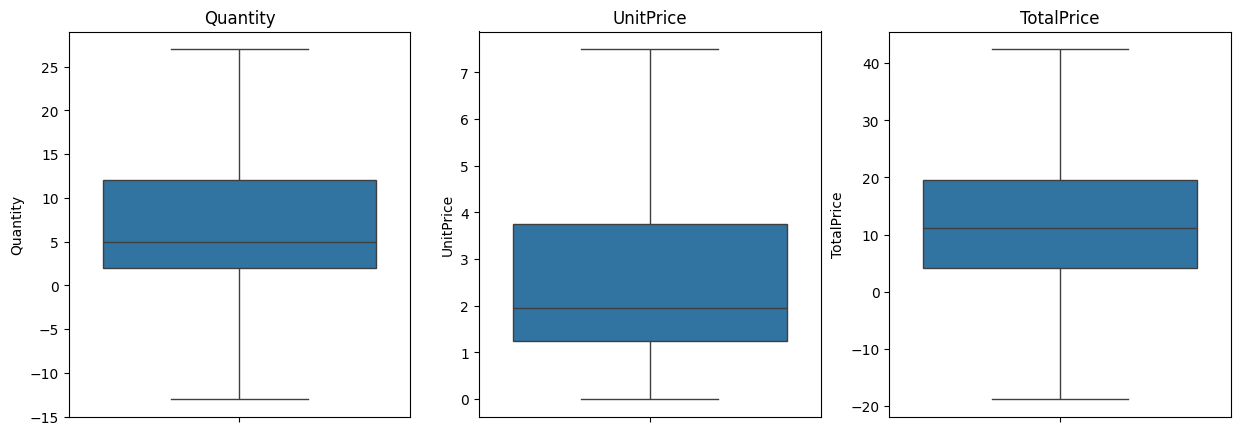

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

col_to_treat = ['Quantity', 'UnitPrice', 'TotalPrice']

fig = plt.figure(figsize=(15, 5))
idx = 1

# Outlier treatment using IQR method
for col in col_to_treat:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper,
                np.where(df[col] < lower, lower, df[col]))

    ax = fig.add_subplot(1, 3, idx)
    sns.boxplot(df[col], ax=ax)
    plt.title(col)
    idx += 1


#**Feature Engineering**

In [ ]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceHour'] = df['InvoiceDate'].dt.hour
df['InvoiceWeekday'] = df['InvoiceDate'].dt.weekday
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


#**Categorical Features**

In [ ]:
# Drop text-heavy or ID-like columns not useful for clustering
df_encoded = df.drop(columns=['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate'])

# One-hot encode 'Country'
df_encoded = pd.get_dummies(df_encoded, columns=['Country'])

# Convert CustomerID to numeric (Label Encoding)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encoded['CustomerID'] = le.fit_transform(df_encoded['CustomerID'])


#**Scale Numeric Features**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded)

# Final DataFrame
df_scaled = pd.DataFrame(scaled_features, columns=df_encoded.columns)


#**Data Scaling**

In [ ]:
# Required libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load dataset (adjust path as needed)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Copy of Online Retail.xlsx - Online Retail.csv')

# Keep only relevant numeric columns
numeric_cols = ['Quantity', 'UnitPrice']

# Drop rows with missing values in numeric columns (or fillna if preferred)
df = df[numeric_cols].dropna()

### 1. Standard Scaling (mean = 0, std = 1)
standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(df[numeric_cols])

# Create DataFrame with scaled values
df_standard_scaled = pd.DataFrame(standard_scaled, columns=numeric_cols)
print("Standard Scaled Data:\n", df_standard_scaled.head())

### 2. Min-Max Scaling (scales between 0 and 1)
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(df[numeric_cols])

# Create DataFrame with scaled values
df_minmax_scaled = pd.DataFrame(minmax_scaled, columns=numeric_cols)
print("\nMin-Max Scaled Data:\n", df_minmax_scaled.head())


Standard Scaled Data:
    Quantity  UnitPrice
0 -0.016289  -0.021301
1 -0.016289  -0.012620
2 -0.007118  -0.019234
3 -0.016289  -0.012620
4 -0.016289  -0.012620

Min-Max Scaled Data:
    Quantity  UnitPrice
0  0.500037   0.221150
1  0.500037   0.221167
2  0.500049   0.221154
3  0.500037   0.221167
4  0.500037   0.221167


#**Data Splitting**

In [ ]:
# Required libraries
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset (already cleaned and preprocessed)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Copy of Online Retail.xlsx - Online Retail.csv')

# Select only relevant numeric and encoded columns
df = df[['Quantity', 'UnitPrice']].dropna()

# Optional: scale data before splitting (recommended)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Split the data (e.g., 80% train, 20% test)
X_train, X_test = train_test_split(scaled_data, test_size=0.2, random_state=42)

# Show the shapes
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (433527, 2)
Testing set shape: (108382, 2)


# **1) KMeans Clustering:**

In [ ]:
#Importing Libraries

from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
!pip install yellowbrick

#***Recency and Monetary***

##***A) Applying Elbow Method on Recency and Monetary.***

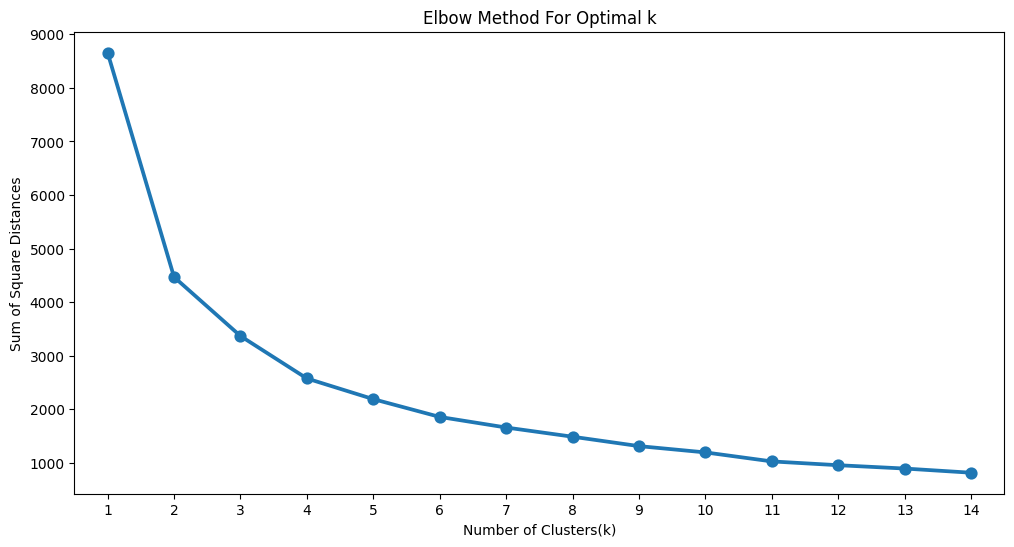

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Filter out negative Monetary values
rfm_dataframe = rfm_dataframe[rfm_dataframe['Monetary'] >= 0]

# taking Recency and Monetory_log in list.
Recency_and_Monetary_feat=['Recency_log','Monetary_log']

# Add log-transformed columns to rfm_dataframe
rfm_dataframe['Recency_log'] = np.log(rfm_dataframe['Recency'] + 1) # Add 1 to handle Recency=0
rfm_dataframe['Monetary_log'] = np.log(rfm_dataframe['Monetary'] + 1) # Add 1 to handle Monetary=0

# taking only values of recency and monetory in X.
X=rfm_dataframe[Recency_and_Monetary_feat].values

# standardising the data
scaler=StandardScaler()
X=scaler.fit_transform(X)

#applying Elbow Method
wcss = {}
for k in range(1,15):
    km = KMeans(n_clusters= k, init= 'k-means++', max_iter= 1000, random_state=42) # Added random_state for reproducibility
    km = km.fit(X)
    wcss[k] = km.inertia_

#Plot the graph for the sum of square distance values and Number of Clusters
plt.figure(figsize=(12,6))
sns.pointplot(x = list(wcss.keys()), y = list(wcss.values()))
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Sum of Square Distances')
plt.title('Elbow Method For Optimal k')
plt.show()

Here we can see that Optimal value for cluster came out to be 2.

##**Cross verifying with ElbowVisualizar**
The elbow method is a heuristic used in determining the number of clusters in a data set. The method consists of plotting the explained variation as a function of the number of clusters, and picking the elbow of the curve as the number of clusters to use.

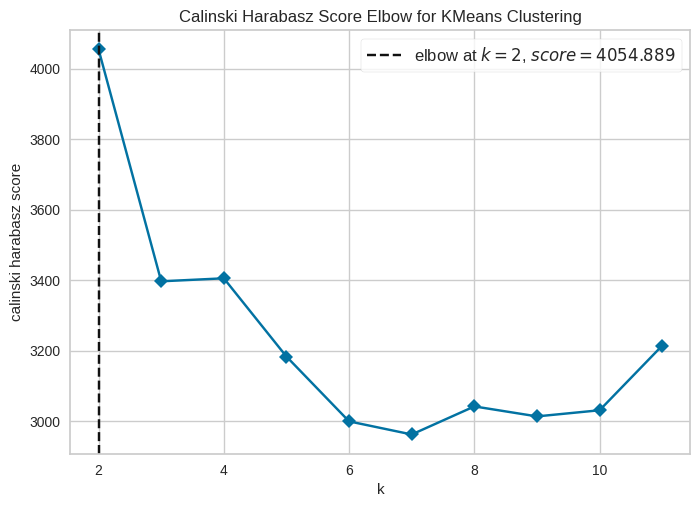

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering model and visualizer
model = KMeans()
visualizer = KElbowVisualizer(
    model, k=(2,12), metric='calinski_harabasz', timings=False
)

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

Elbow Visulaizer also giving cluster=2

##**Silhouette Score** ***(Validating Above optimal cluster value(i.e optimal_cluster=2)***

In [ ]:
# taking Recency and Monetory_log in list.
Recency_and_Monetary_feat=['Recency_log','Monetary_log']

# taking only values of recency and monetory in X.
X=rfm_dataframe[Recency_and_Monetary_feat].values

# standardising the data
scaler=StandardScaler()
X=scaler.fit_transform(X)

#Silhouette Score
range_n_clusters = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters,random_state=1)
    preds = clusterer.fit_predict(X)
    centers = clusterer.cluster_centers_

    score = silhouette_score(X, preds)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

For n_clusters = 2, silhouette score is 0.4194706559733057
For n_clusters = 3, silhouette score is 0.3395172882723491
For n_clusters = 4, silhouette score is 0.36338455544161813
For n_clusters = 5, silhouette score is 0.327922669831983
For n_clusters = 6, silhouette score is 0.3355819069775805
For n_clusters = 7, silhouette score is 0.33015110796474323
For n_clusters = 8, silhouette score is 0.3301144286648926
For n_clusters = 9, silhouette score is 0.35149800969554834
For n_clusters = 10, silhouette score is 0.34026580889809965
For n_clusters = 11, silhouette score is 0.34735928049160447
For n_clusters = 12, silhouette score is 0.3375049176988937
For n_clusters = 13, silhouette score is 0.33420668426878936
For n_clusters = 14, silhouette score is 0.3250098206676567
For n_clusters = 15, silhouette score is 0.33505521500114943


***Here we can see the for n_cluster=2 silhouette score is better as compared to others.(if values is close to 1 means data points are clustered very well to respective clusters and distance of that datapoint is very far from the other cluster.)***

For n_clusters = 2 The average silhouette_score is : 0.4194706559733057
For n_clusters = 3 The average silhouette_score is : 0.3395172882723491
For n_clusters = 4 The average silhouette_score is : 0.36338455544161813
For n_clusters = 5 The average silhouette_score is : 0.327922669831983
For n_clusters = 6 The average silhouette_score is : 0.3355819069775805
For n_clusters = 7 The average silhouette_score is : 0.33015110796474323
For n_clusters = 8 The average silhouette_score is : 0.3301144286648926
For n_clusters = 9 The average silhouette_score is : 0.35149800969554834
For n_clusters = 10 The average silhouette_score is : 0.34026580889809965


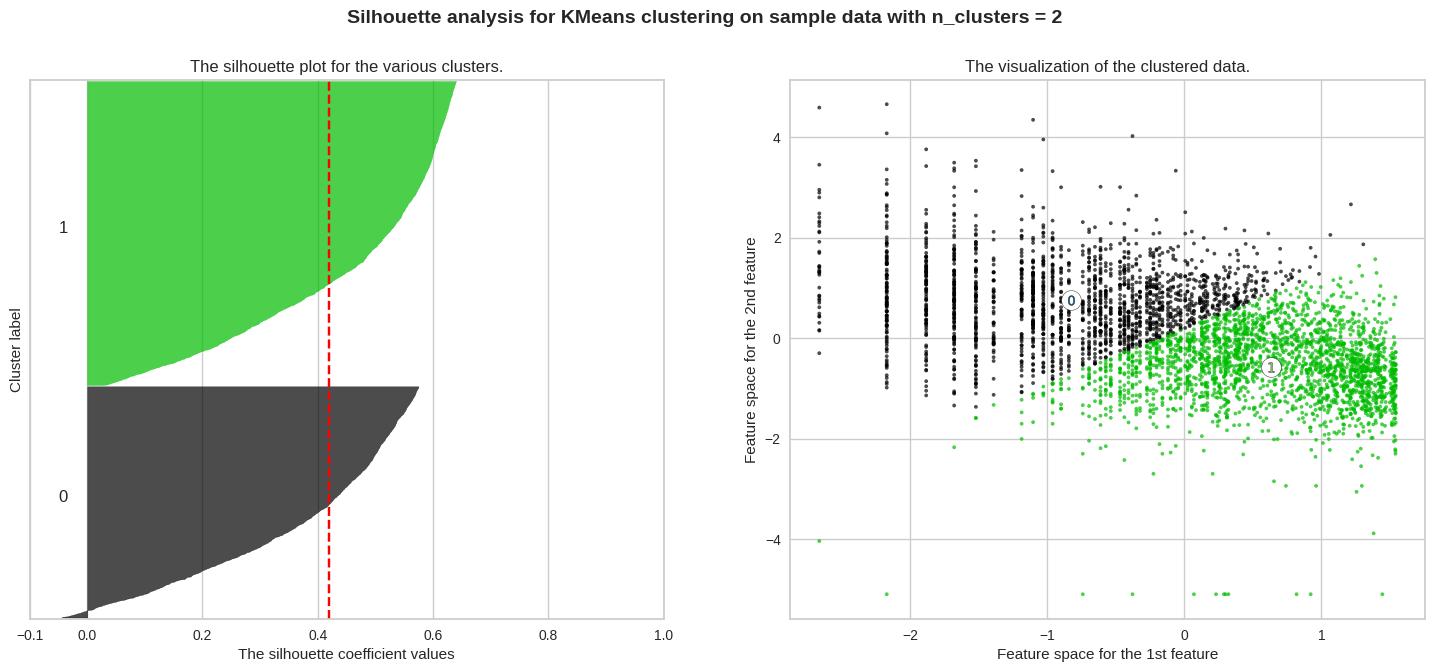

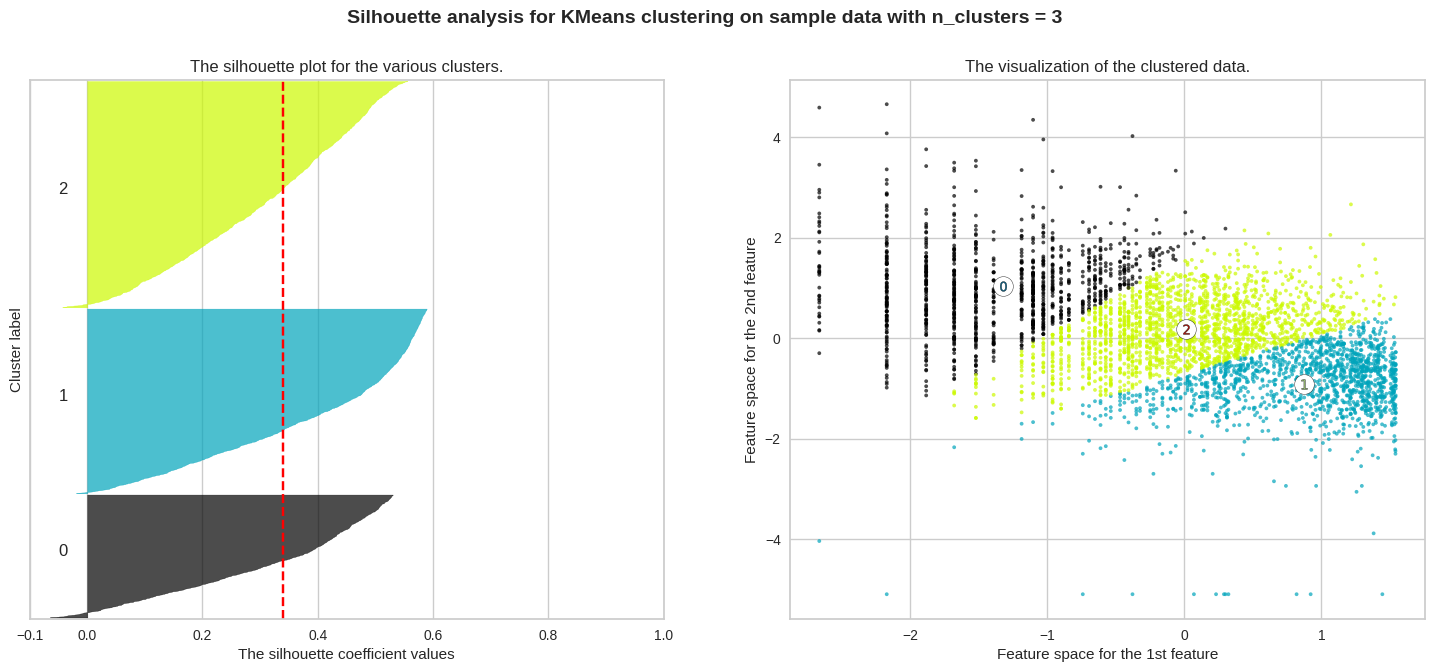

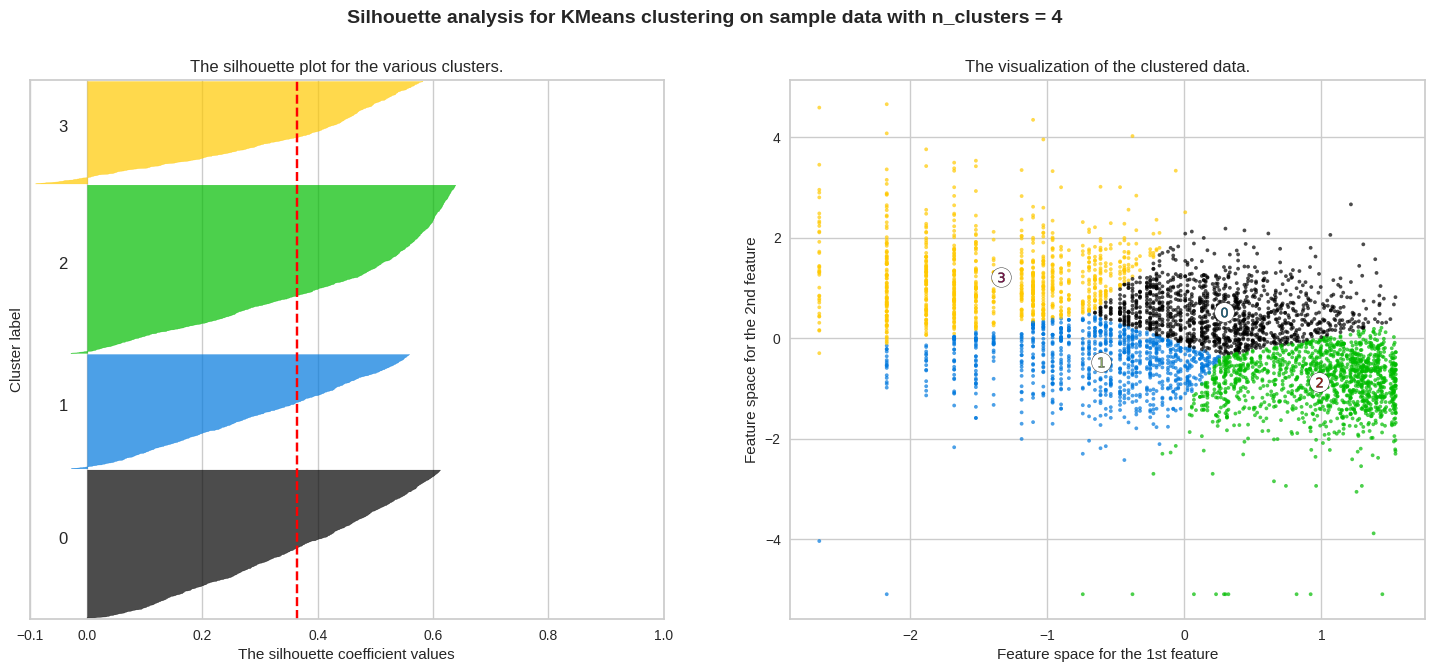

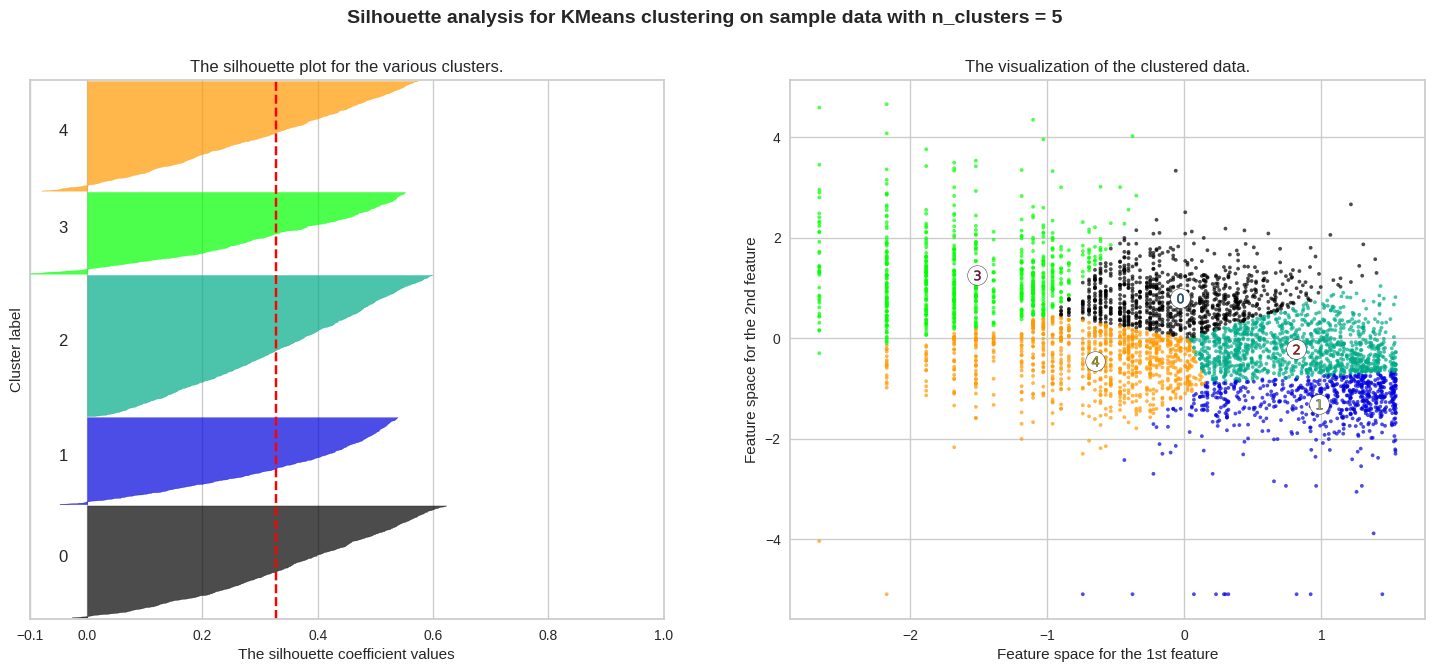

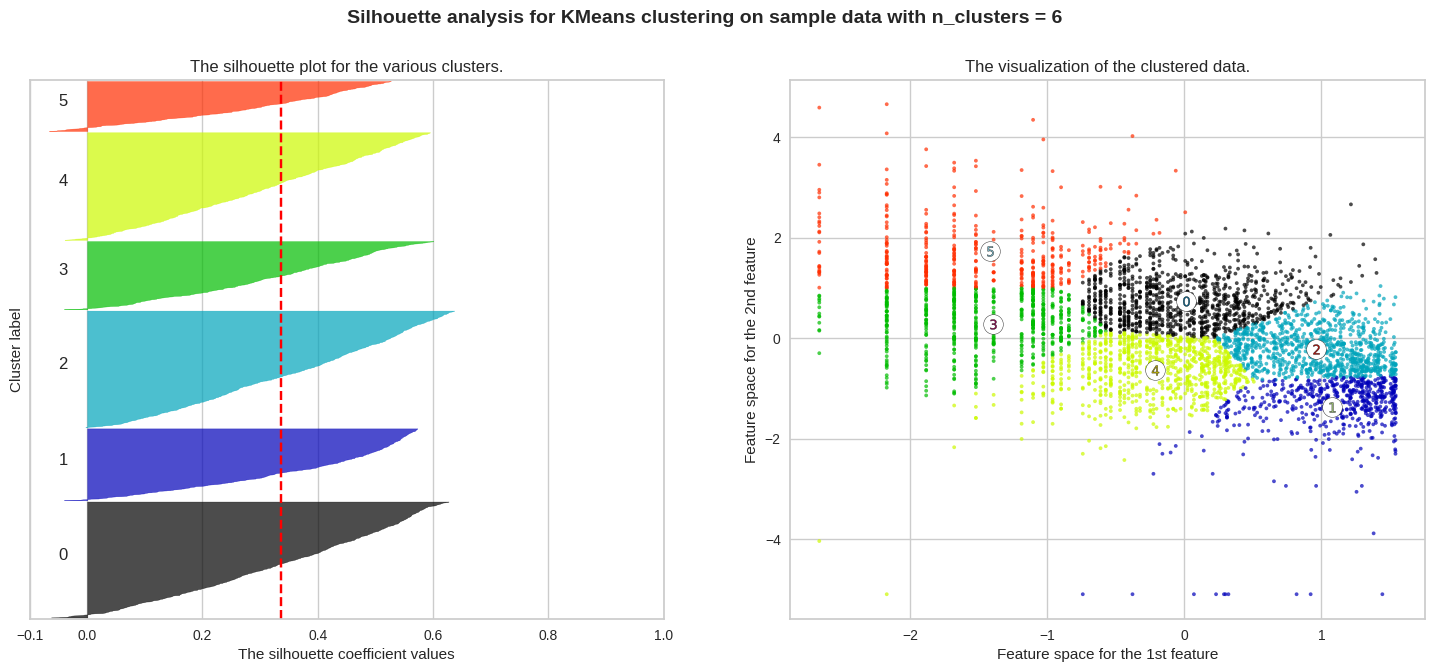

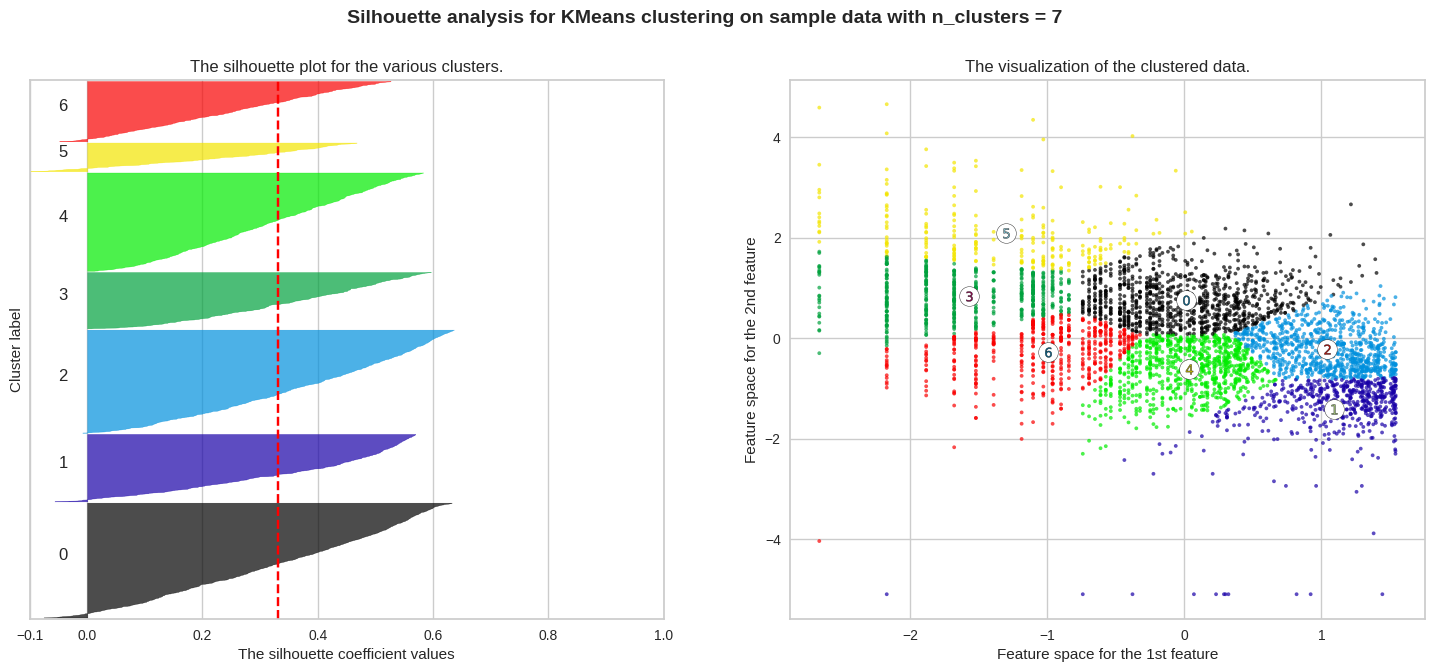

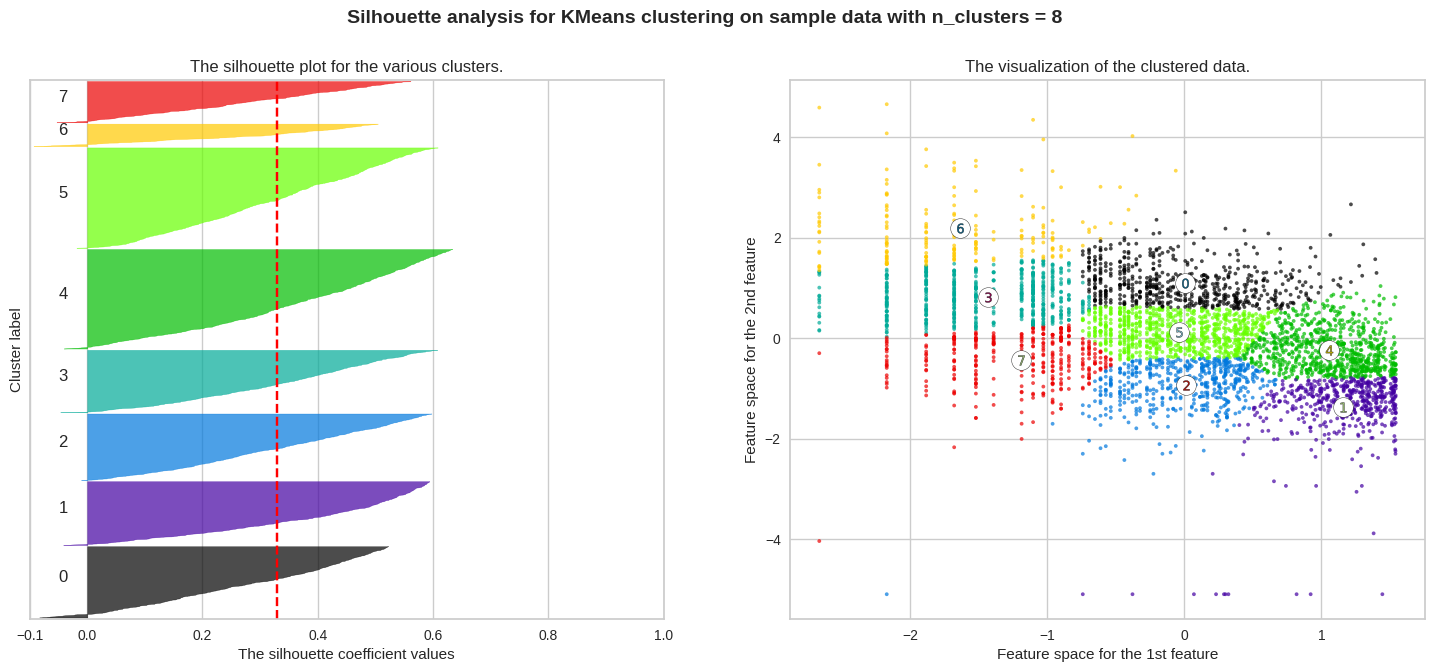

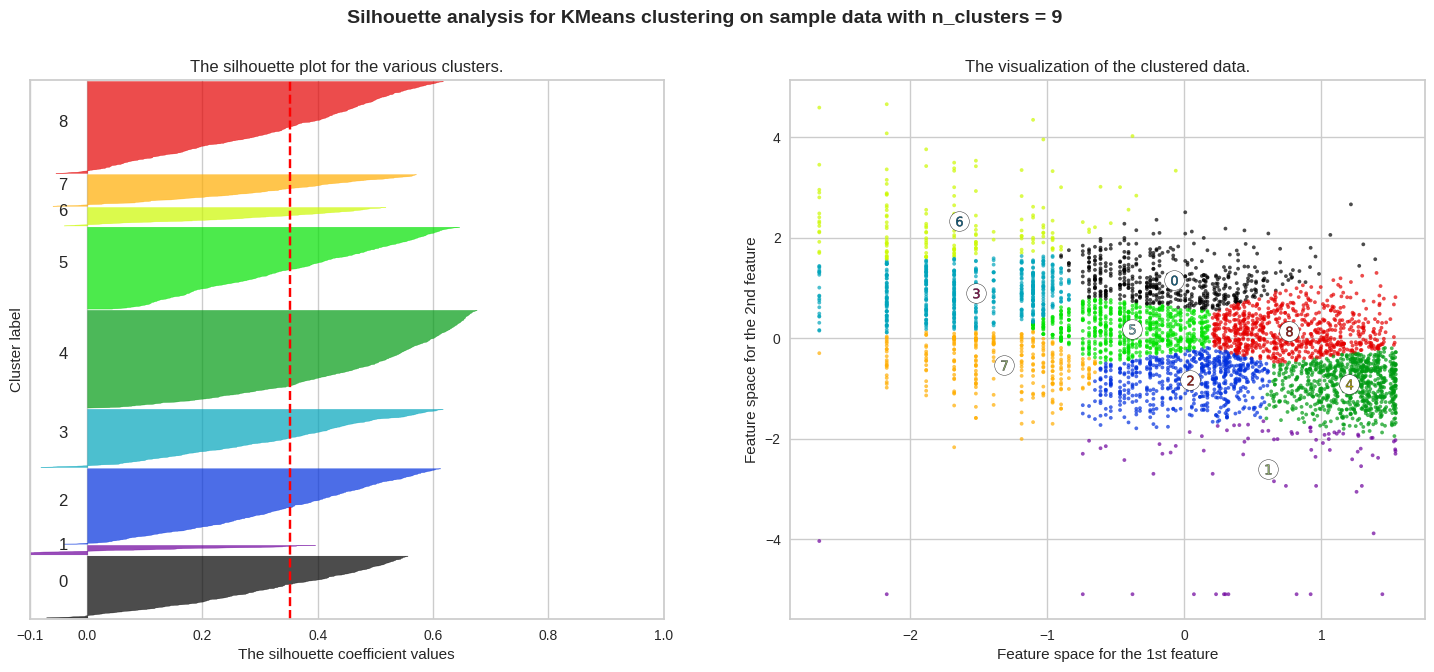

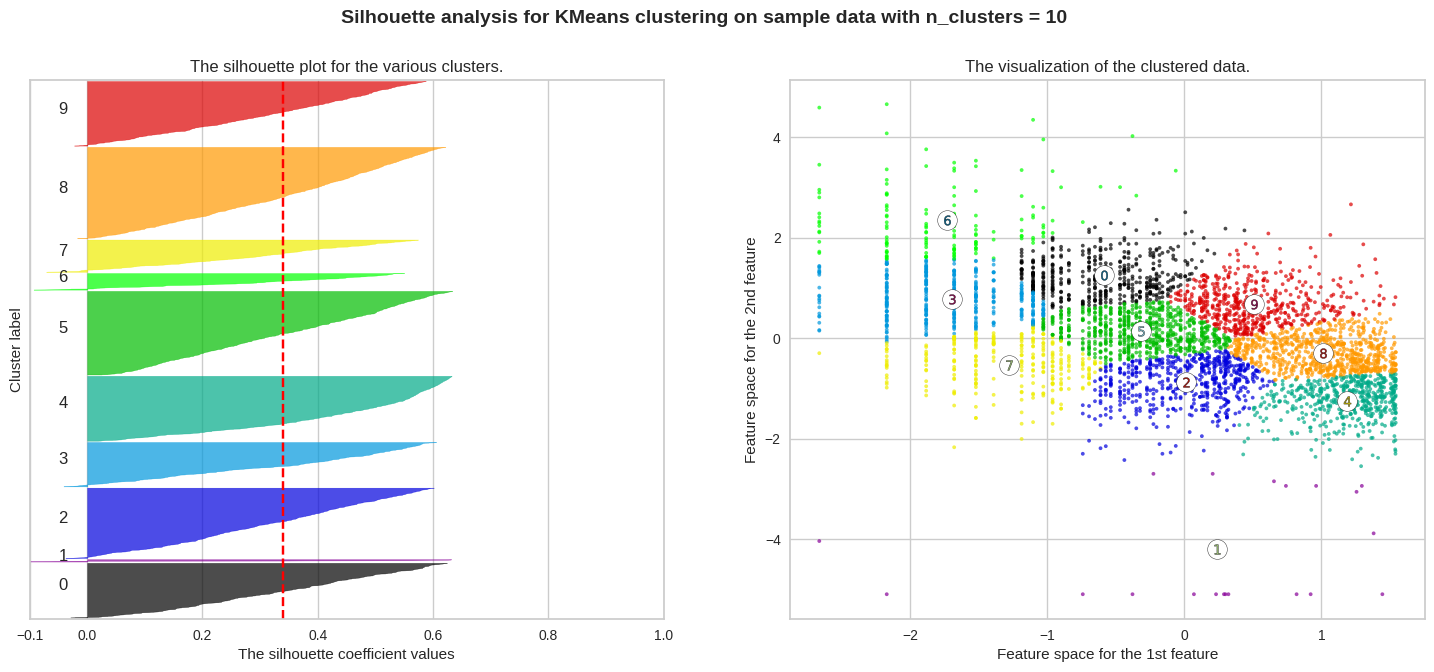

In [ ]:

from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

range_n_clusters = [2,3,4,5,6,7,8,9,10]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) /n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")
    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()



* ***We got good Silhouette plot for Cluster-2 but still few datapoints are on the negative side of the Silhouette Coefficient value as shown in below figure. but its better than others***

###**So giving n_clusters=2 on Kmeans Model.**

In [ ]:
# applying Kmeans_clustering algorithm
kmeans_rec_mon = KMeans(n_clusters=2)
kmeans_rec_mon.fit(X)
y_kmeans= kmeans_rec_mon.predict(X)

In [ ]:
#Find the clusters for the observation given in the dataset
rfm_dataframe['Cluster_based_rec_mon'] = kmeans_rec_mon.labels_
rfm_dataframe.head(10)

,Recency,Frequency,Monetary,Recency_log,Monetary_log,Cluster_based_rec_mon
CustomerID,,,,,,
12346.0,325,2,0.00,5.786897,0.000000,0
12347.0,2,182,4310.00,1.098612,8.368925,1
12348.0,75,31,1797.24,4.330733,7.494564,1
12349.0,18,73,1757.55,2.944439,7.472245,1
12350.0,310,17,334.40,5.739793,5.815324,0
12352.0,36,95,1545.41,3.610918,7.343691,1
12353.0,204,4,89.00,5.323010,4.499810,0
12354.0,232,58,1079.40,5.451038,6.985087,0
12355.0,214,13,459.40,5.370638,6.132096,0


In [ ]:
# Centers of the clusters(coordinates)
centers = kmeans_rec_mon.cluster_centers_
centers

array([[ 0.63395655, -0.58411232],
       [-0.82549235,  0.76058881]])

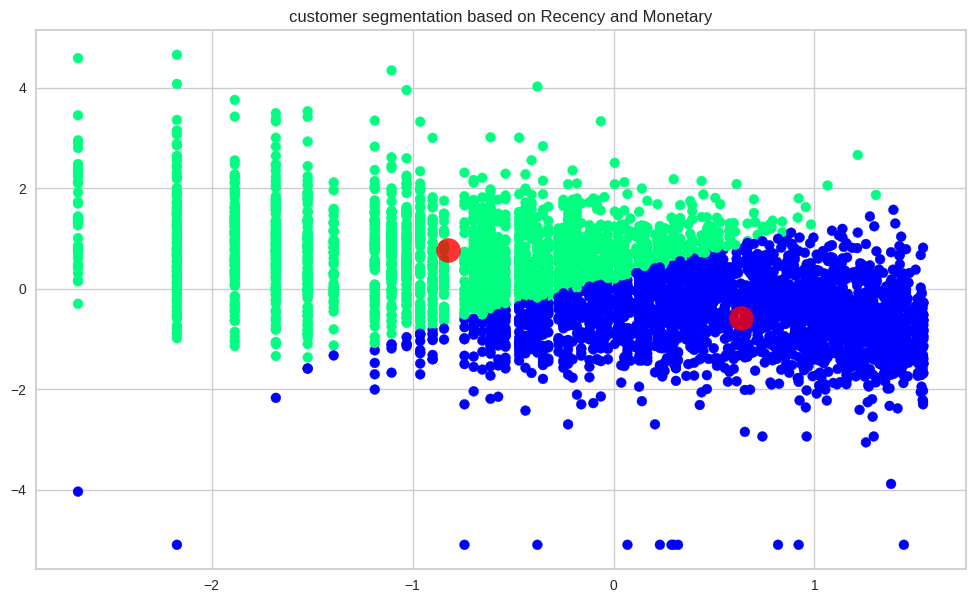

In [ ]:
# ploting visualizing the clusters
plt.figure(figsize=(12,7))
plt.title('customer segmentation based on Recency and Monetary')
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='winter')

centers = kmeans_rec_mon.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=300, alpha=0.8)

#***Frequency and Monetary***

##**1) KMeans Clustering**

#***A)  Applying Elbow Method on Frequency and Monetary.***

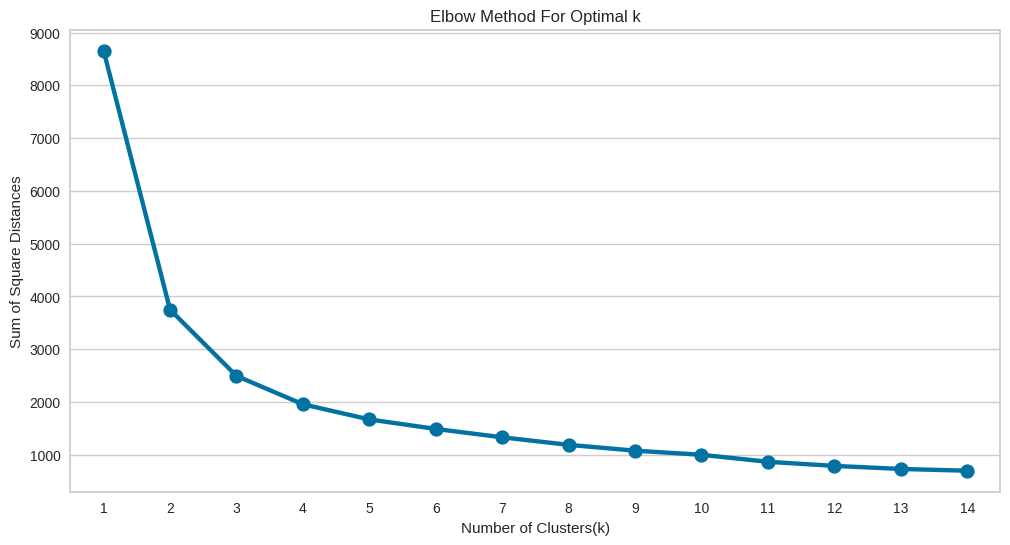

In [ ]:
# taking Frequency and Monetory_log in list.
Frequency_and_Monetary_feat=['Frequency_log','Monetary_log']

# Add log-transformed column to rfm_dataframe
rfm_dataframe['Frequency_log'] = np.log(rfm_dataframe['Frequency'] + 1) # Add 1 to handle Frequency=0

# taking only values of frequency and monetory in X.
X=rfm_dataframe[Frequency_and_Monetary_feat].values

# standardising the data
scaler=StandardScaler()
X=scaler.fit_transform(X)

#applying Elbow Method
wcss = {}
for k in range(1,15):
    km = KMeans(n_clusters= k, init= 'k-means++', max_iter= 1000)
    km = km.fit(X)
    wcss[k] = km.inertia_


#Plot the graph for the sum of square distance values and Number of Clusters
plt.figure(figsize=(12,6))
sns.pointplot(x = list(wcss.keys()), y = list(wcss.values()))
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Sum of Square Distances')
plt.title('Elbow Method For Optimal k')
plt.show()

**Here we can see that Optimal value for cluster came out to be 2.**

##***Cross verifying with ElbowVisualizar***

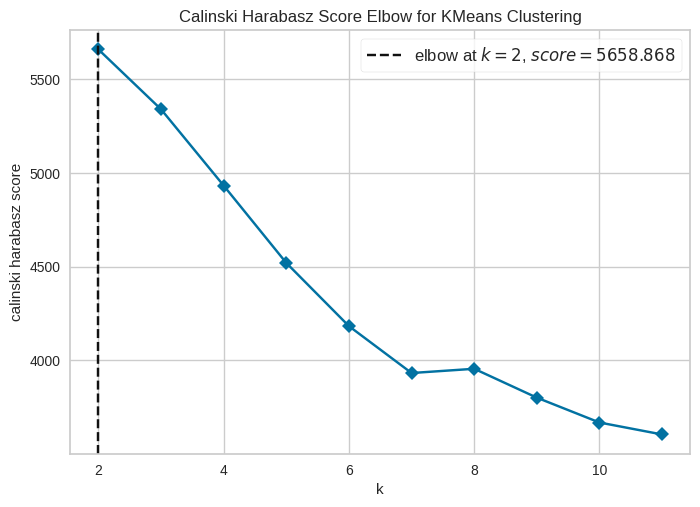

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering model and visualizer
model = KMeans()
visualizer = KElbowVisualizer(
    model, k=(2,12), metric='calinski_harabasz', timings=False
)

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

Elbow Visulaizer also giving cluster=2

##**Silhouette Score** ***(Validating Above optimal cluster value(i.e optimal_cluster=2)***

In [ ]:
# taking Recency and Monetory_log in list.
Recency_and_Monetary_feat=['Frequency_log','Monetary_log']

# taking only values of recency and monetory in X.
X=rfm_dataframe[Recency_and_Monetary_feat].values

# standardising the data
scaler=StandardScaler()
X=scaler.fit_transform(X)

#Silhouette Score
range_n_clusters = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters,random_state=1)
    preds = clusterer.fit_predict(X)
    centers = clusterer.cluster_centers_

    score = silhouette_score(X, preds)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

For n_clusters = 2, silhouette score is 0.4828544371750105
For n_clusters = 3, silhouette score is 0.40986124172862365
For n_clusters = 4, silhouette score is 0.3715526534120087
For n_clusters = 5, silhouette score is 0.34378816261643363
For n_clusters = 6, silhouette score is 0.3487918463741105
For n_clusters = 7, silhouette score is 0.32973142379317505
For n_clusters = 8, silhouette score is 0.3489678049648985
For n_clusters = 9, silhouette score is 0.34240617110492316
For n_clusters = 10, silhouette score is 0.32595234221765856
For n_clusters = 11, silhouette score is 0.34738504191313574
For n_clusters = 12, silhouette score is 0.3657907173271033
For n_clusters = 13, silhouette score is 0.3507192842408296
For n_clusters = 14, silhouette score is 0.36011210956639417
For n_clusters = 15, silhouette score is 0.36140741920137914


***Here we can see the for n_cluster=2 silhouette score is good as compared to others.(if values is close to 1 means data points are clustered very well to respective clusters and distance of that datapoint is very far from the other cluster.)***

For n_clusters = 2 The average silhouette_score is : 0.4828544371750105
For n_clusters = 3 The average silhouette_score is : 0.40986124172862365
For n_clusters = 4 The average silhouette_score is : 0.3715526534120087
For n_clusters = 5 The average silhouette_score is : 0.34378816261643363
For n_clusters = 6 The average silhouette_score is : 0.3487918463741105
For n_clusters = 7 The average silhouette_score is : 0.32973142379317505
For n_clusters = 8 The average silhouette_score is : 0.3489678049648985
For n_clusters = 9 The average silhouette_score is : 0.34240617110492316
For n_clusters = 10 The average silhouette_score is : 0.32595234221765856


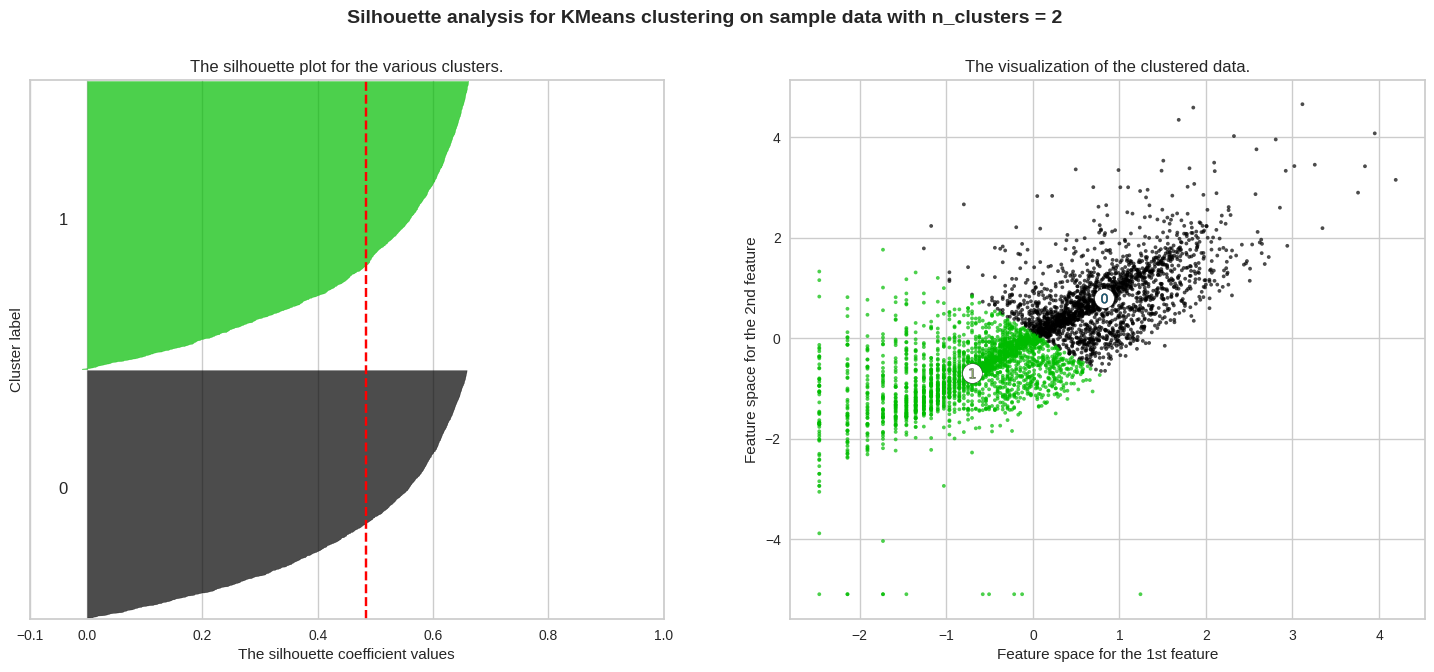

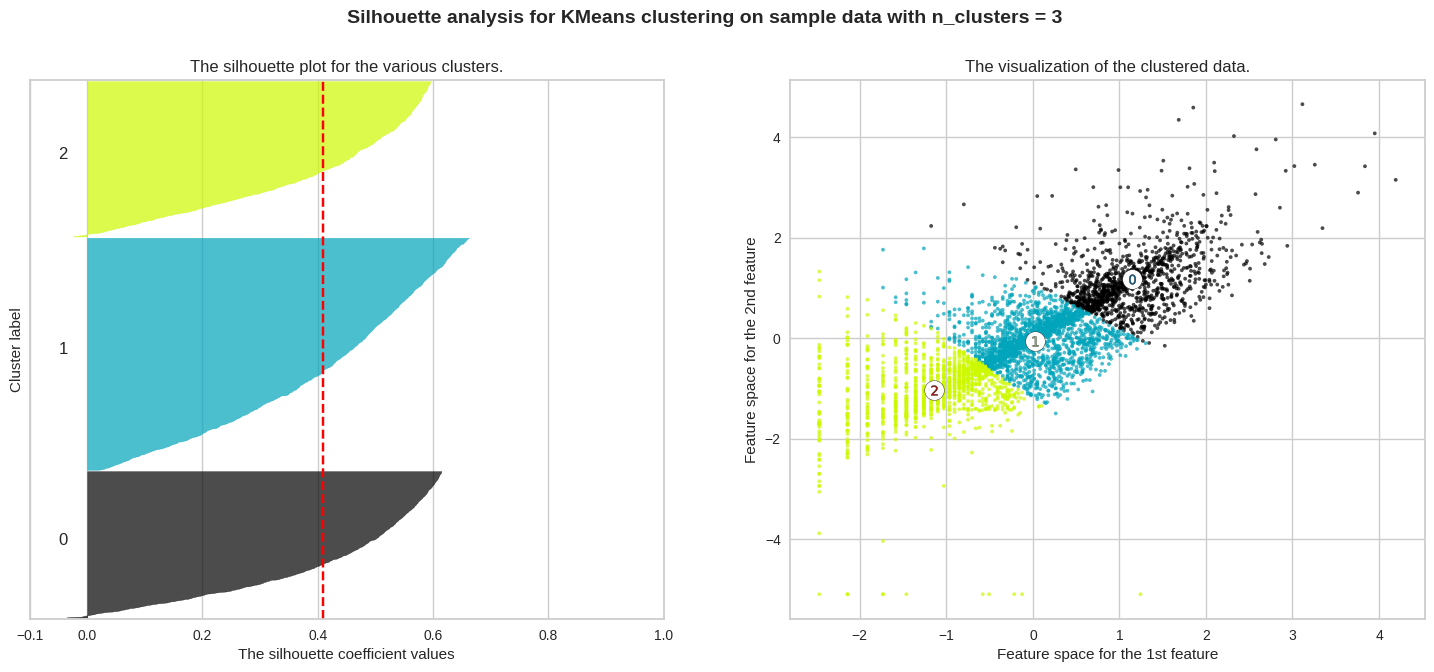

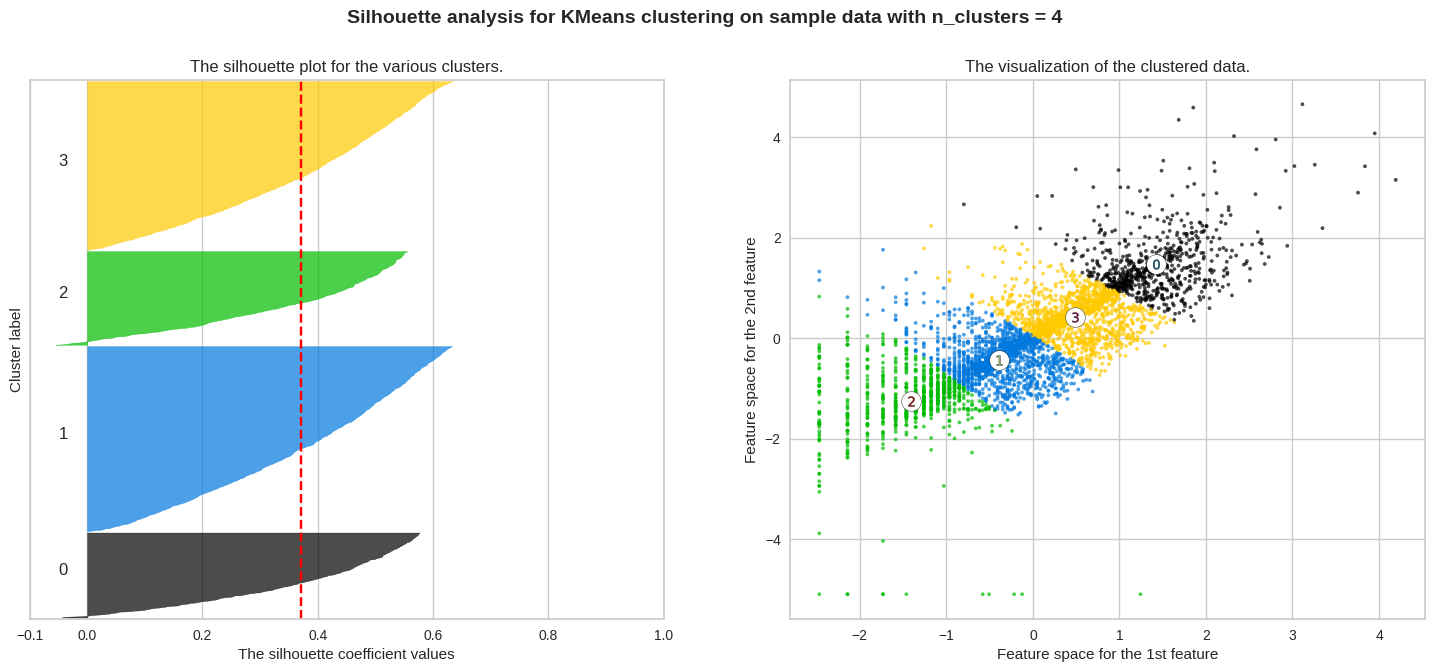

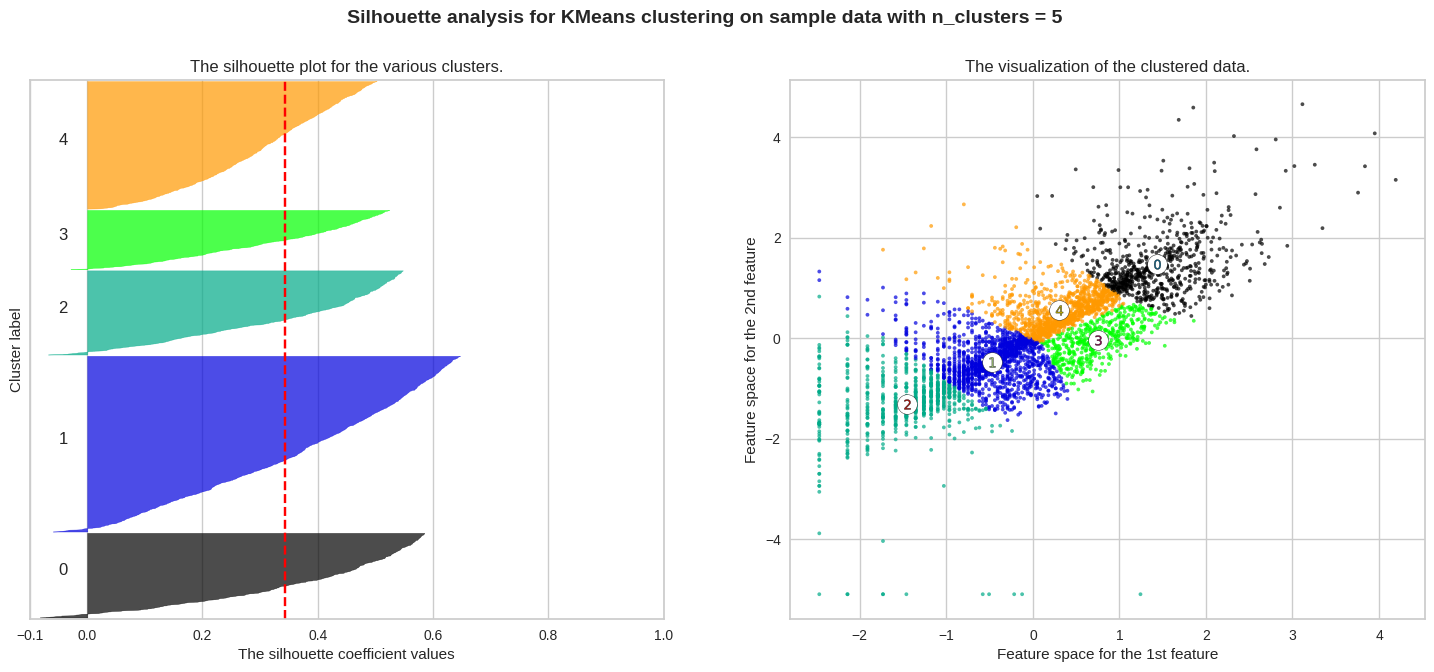

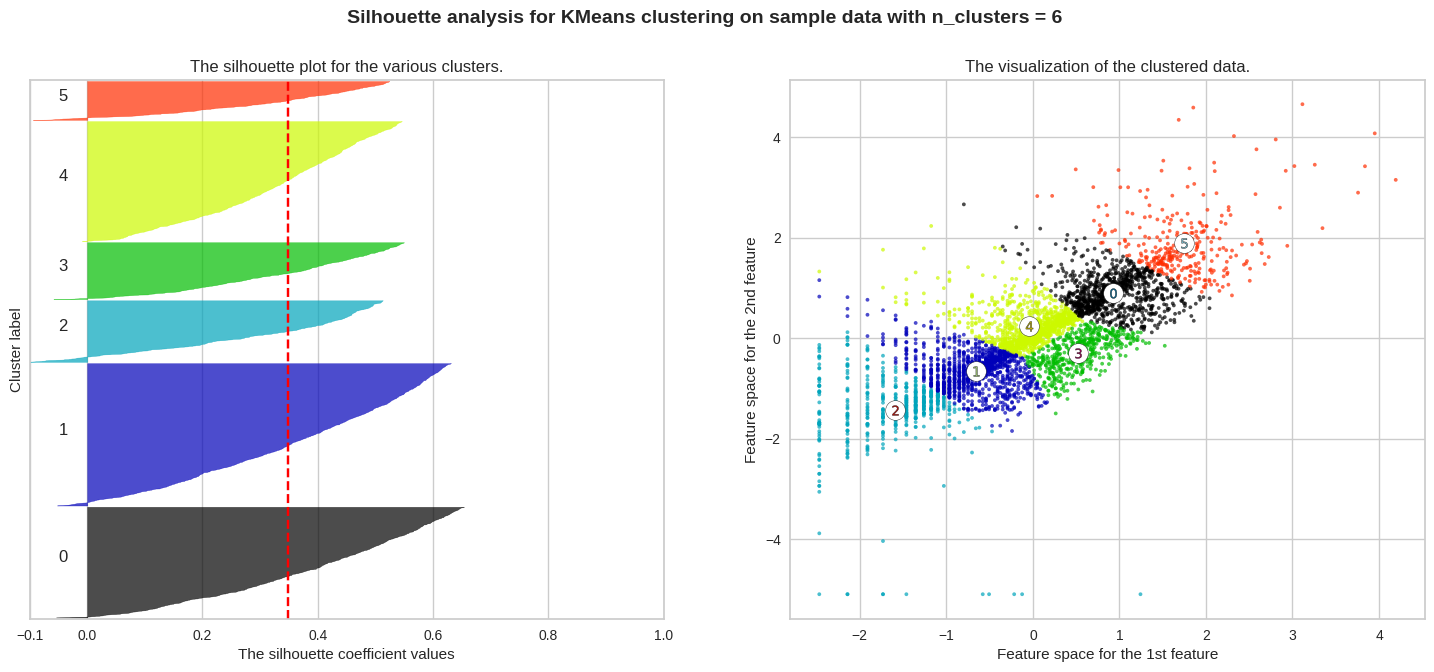

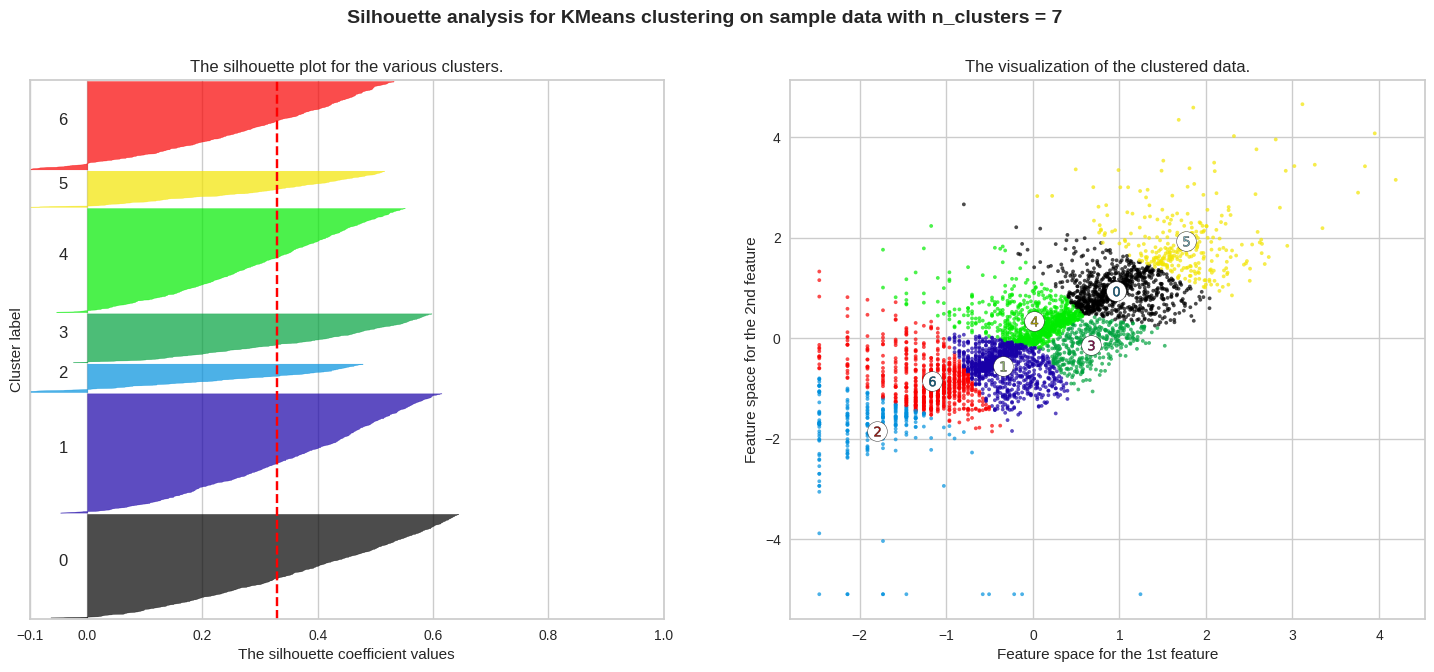

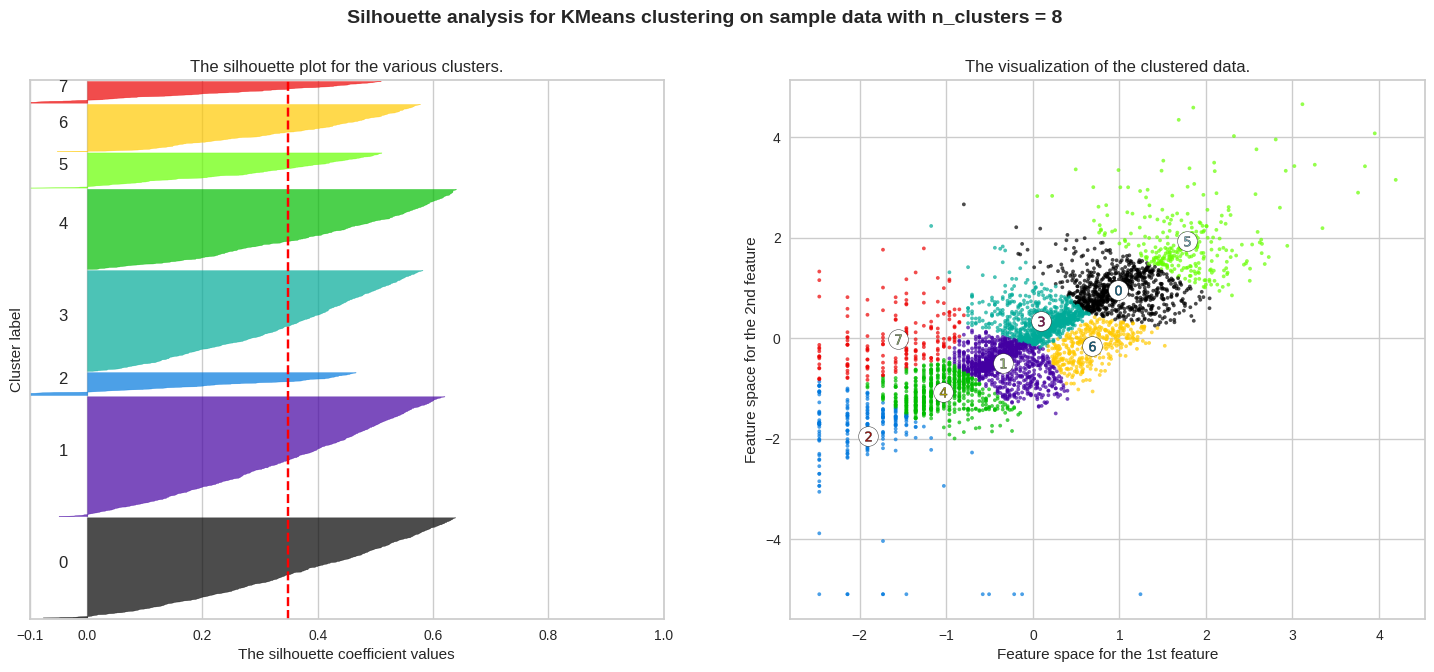

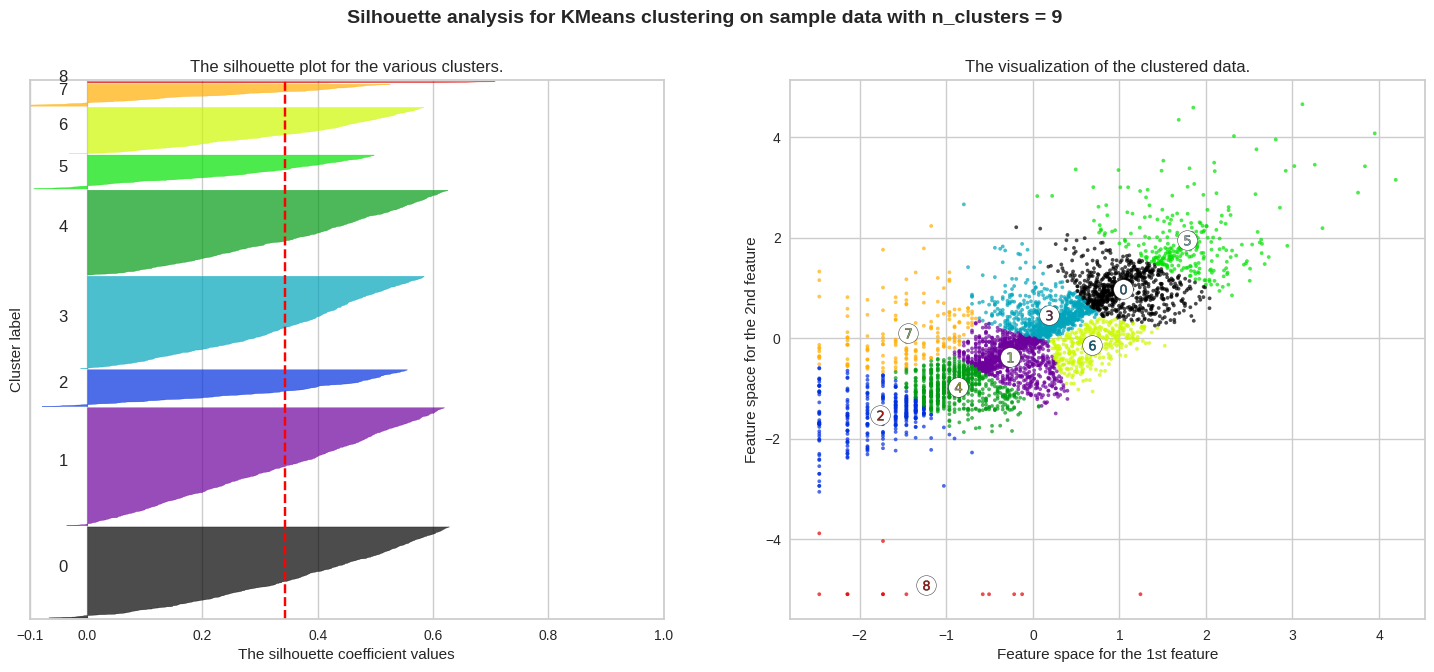

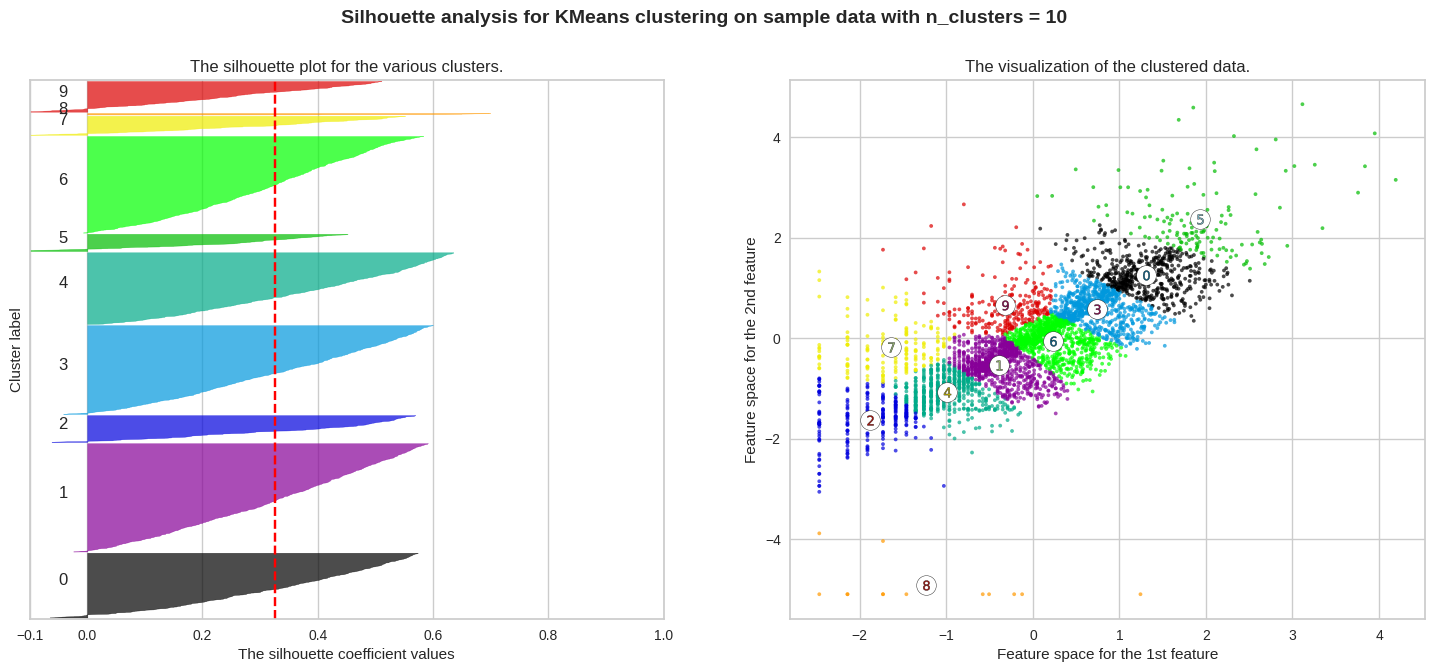

In [ ]:

from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

range_n_clusters = [2,3,4,5,6,7,8,9,10]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) /n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")
    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()


**So giving n_clusters=2 on Kmeans Model.**

In [ ]:
# applying Kmeans_clustering algorithm
kmeans_freq_mon = KMeans(n_clusters=2)
kmeans_freq_mon.fit(X)
y_kmeans= kmeans_freq_mon.predict(X)

In [ ]:
#Find the clusters for the observation given in the dataset
rfm_dataframe['Cluster_based_on_freq_mon'] = kmeans_freq_mon.labels_
rfm_dataframe.head(10)

,Recency,Frequency,Monetary,Recency_log,Monetary_log,Cluster_based_rec_mon,Frequency_log,Cluster_based_on_freq_mon
CustomerID,,,,,,,,
12346.0,325,2,0.00,5.786897,0.000000,0,1.098612,0
12347.0,2,182,4310.00,1.098612,8.368925,1,5.209486,1
12348.0,75,31,1797.24,4.330733,7.494564,1,3.465736,1
12349.0,18,73,1757.55,2.944439,7.472245,1,4.304065,1
12350.0,310,17,334.40,5.739793,5.815324,0,2.890372,0
12352.0,36,95,1545.41,3.610918,7.343691,1,4.564348,1
12353.0,204,4,89.00,5.323010,4.499810,0,1.609438,0
12354.0,232,58,1079.40,5.451038,6.985087,0,4.077537,1
12355.0,214,13,459.40,5.370638,6.132096,0,2.639057,0


In [ ]:
# Centers of the clusters(coordinates)
centers = kmeans_freq_mon.cluster_centers_
centers

array([[-0.70398773, -0.68298947],
       [ 0.82940879,  0.80466953]])

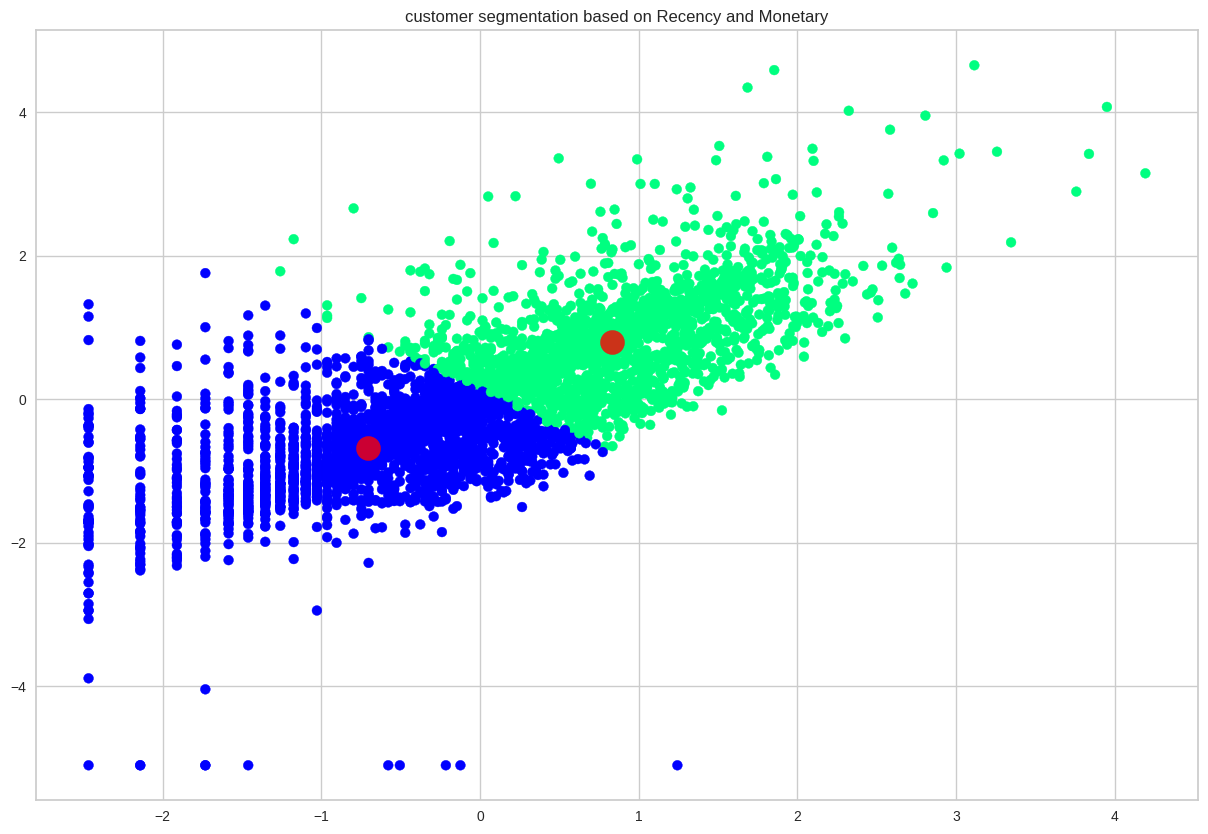

In [ ]:
# ploting visualizing the clusters
plt.figure(figsize=(15,10))
plt.title('customer segmentation based on Recency and Monetary')
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='winter')

centers = kmeans_freq_mon.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=300, alpha=0.8)

#**Recency,Frequency and Monetary**

# **1) KMeans Clustering**

#***A) Applying Elbow Method on Recency, Frequency and Monetary.***

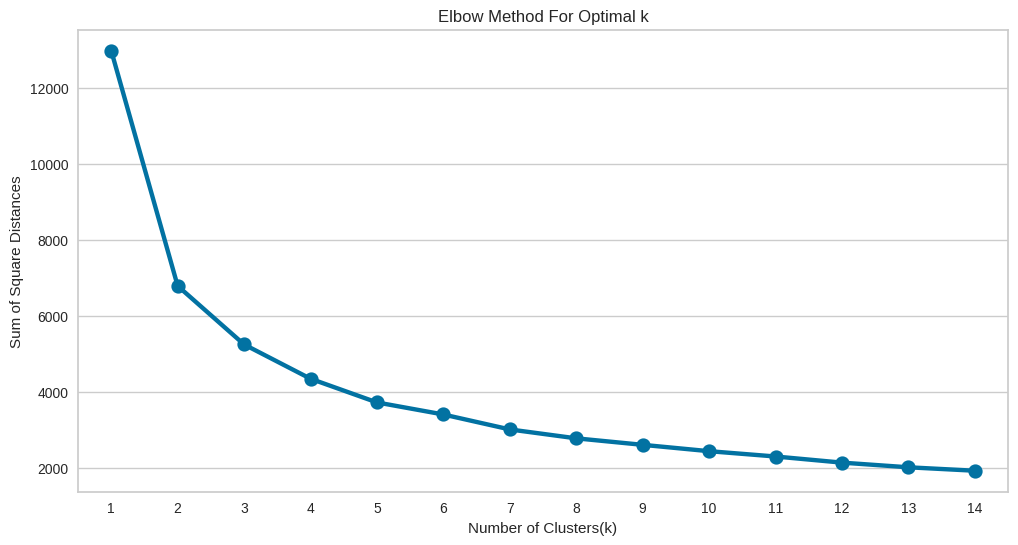

In [ ]:
# taking Recency_log, Frequency_log and Monetory_log in list.
Recency_and_Monetary_feat=['Recency_log','Frequency_log','Monetary_log']

# taking only values of recency and monetory in X.
X=rfm_dataframe[Recency_and_Monetary_feat].values

# standardising the data
scaler=StandardScaler()
X=scaler.fit_transform(X)

#applying Elbow Method
wcss = {}
for k in range(1,15):
    km = KMeans(n_clusters= k, init= 'k-means++', max_iter= 1000)
    km = km.fit(X)
    wcss[k] = km.inertia_


#Plot the graph for the sum of square distance values and Number of Clusters
plt.figure(figsize=(12,6))
sns.pointplot(x = list(wcss.keys()), y = list(wcss.values()))
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Sum of Square Distances')
plt.title('Elbow Method For Optimal k')
plt.show()

# **Here we can see that Optimal value for cluster came out to be 2.**

##***Cross verifying with ElbowVisualizar***

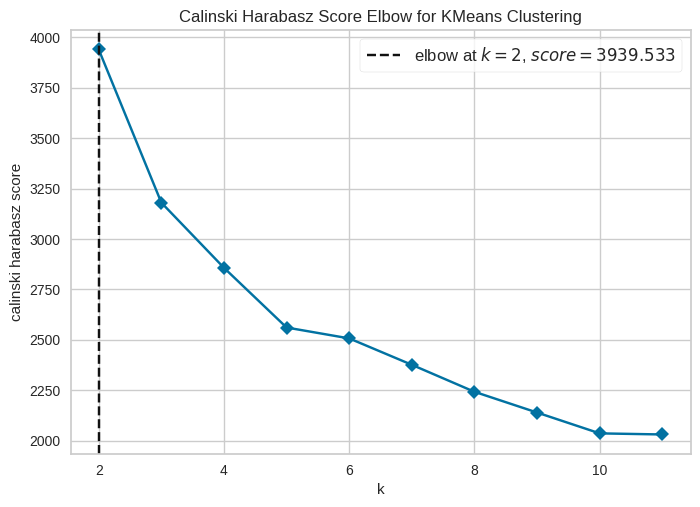

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering model and visualizer
model = KMeans()
visualizer = KElbowVisualizer(
    model, k=(2,12), metric='calinski_harabasz', timings=False
)

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

Elbow Visulaizer also giving cluster=2

# **Silhouette Score (Validating Above optimal cluster value(i.e optimal_cluster=2)**

In [ ]:
# taking Recency_log,Frequency_log and Monetory_log in list.
Recency_and_Monetary_feat=['Recency_log','Frequency_log','Monetary_log']

# taking only values of recency and monetory in X.
X=rfm_dataframe[Recency_and_Monetary_feat].values

# standardising the data
scaler=StandardScaler()
X=scaler.fit_transform(X)

#Silhouette Score
range_n_clusters = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters,random_state=1)
    preds = clusterer.fit_predict(X)
    centers = clusterer.cluster_centers_

    score = silhouette_score(X, preds)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

For n_clusters = 2, silhouette score is 0.3999320405662772
For n_clusters = 3, silhouette score is 0.30587211361228456
For n_clusters = 4, silhouette score is 0.30914543946871076
For n_clusters = 5, silhouette score is 0.2778737253091083
For n_clusters = 6, silhouette score is 0.2747472050829611
For n_clusters = 7, silhouette score is 0.2625269378738135
For n_clusters = 8, silhouette score is 0.25985928767565414
For n_clusters = 9, silhouette score is 0.2549287400879882
For n_clusters = 10, silhouette score is 0.23922150840186515
For n_clusters = 11, silhouette score is 0.24100576521134456
For n_clusters = 12, silhouette score is 0.24941273070608622
For n_clusters = 13, silhouette score is 0.25725488702260724
For n_clusters = 14, silhouette score is 0.25308980155467947
For n_clusters = 15, silhouette score is 0.24831447172548493


***Here we can see the for n_cluster=2 silhouette score is good as compared to others.(if values is close to 1 means data points are clustered very well to respective clusters and distance of that datapoint is very far from the other cluster.)***

For n_clusters = 2 The average silhouette_score is : 0.3999320405662772
For n_clusters = 3 The average silhouette_score is : 0.30587211361228456
For n_clusters = 4 The average silhouette_score is : 0.30914543946871076
For n_clusters = 5 The average silhouette_score is : 0.2778737253091083
For n_clusters = 6 The average silhouette_score is : 0.2747472050829611
For n_clusters = 7 The average silhouette_score is : 0.2625269378738135
For n_clusters = 8 The average silhouette_score is : 0.25985928767565414
For n_clusters = 9 The average silhouette_score is : 0.2549287400879882
For n_clusters = 10 The average silhouette_score is : 0.23922150840186515


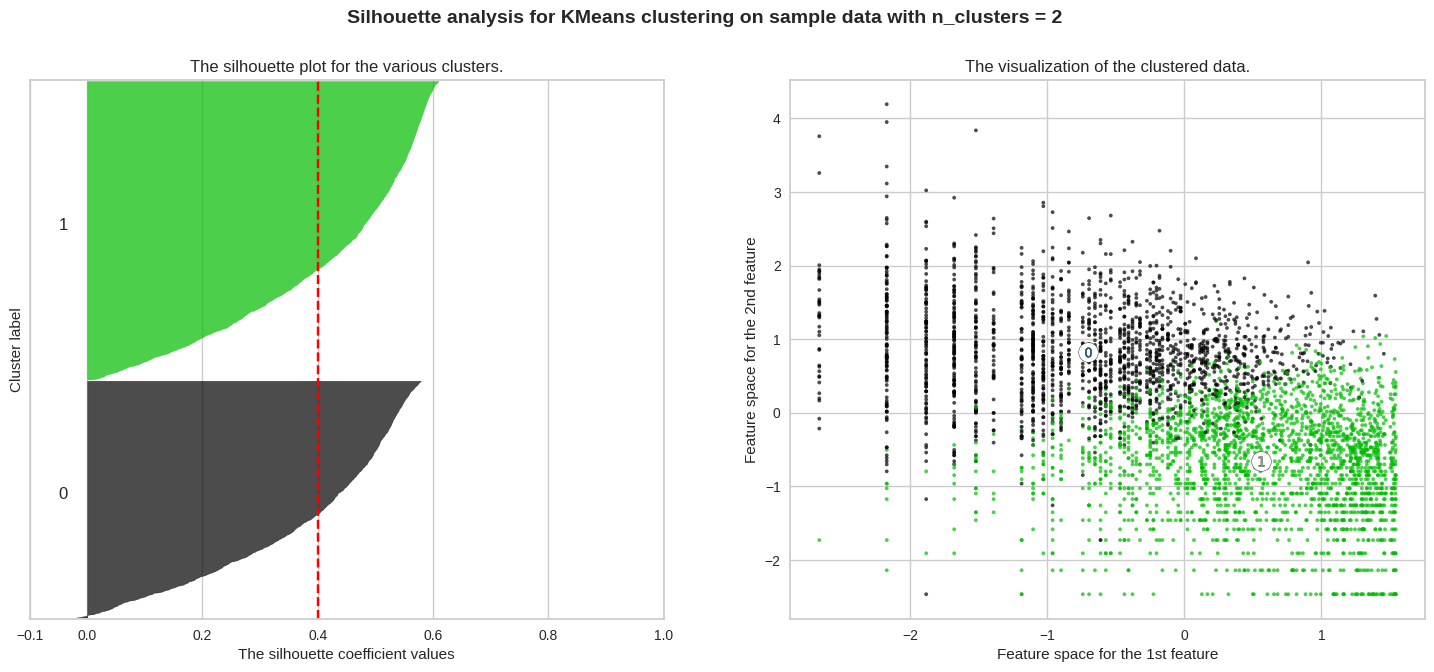

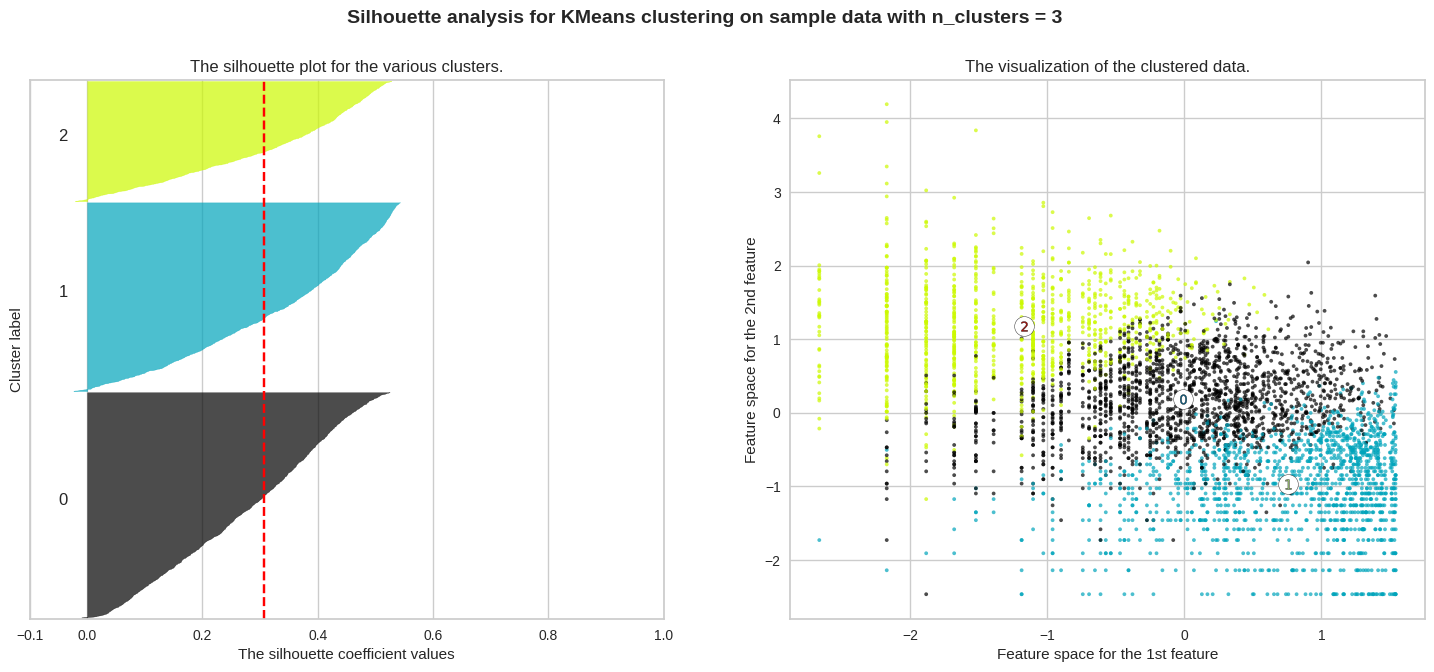

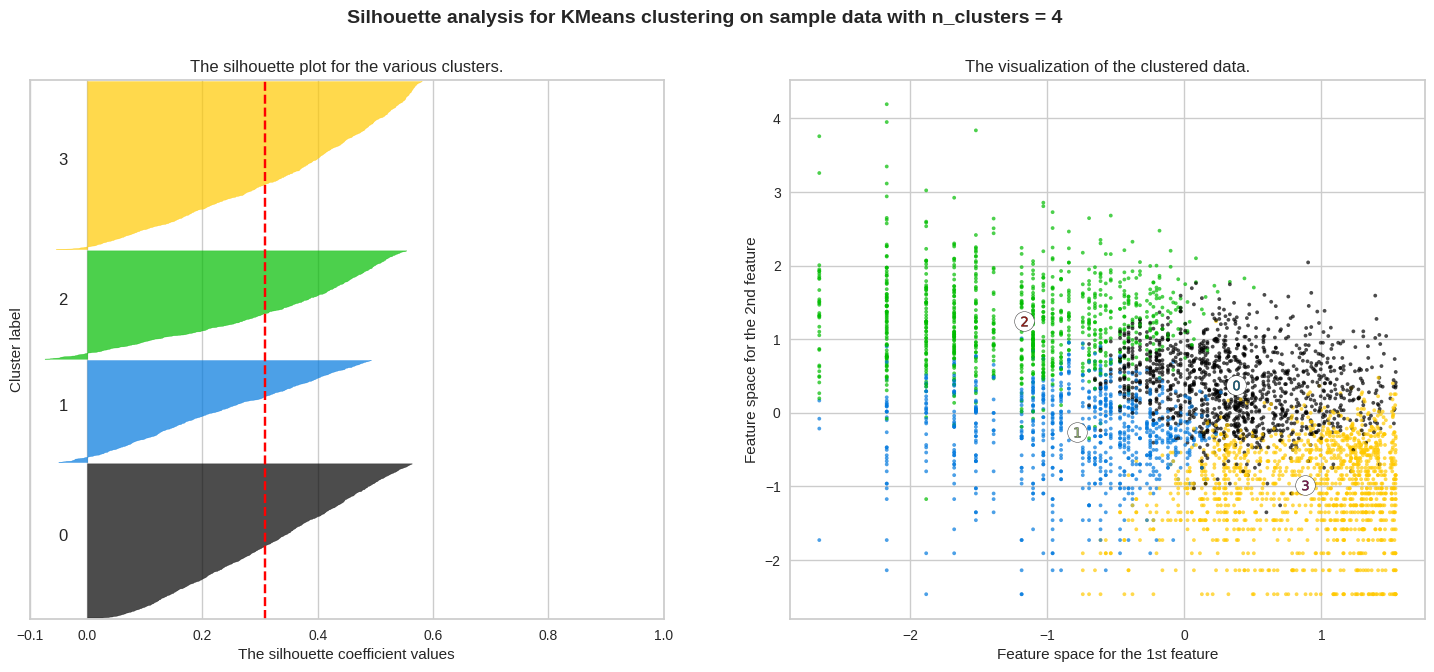

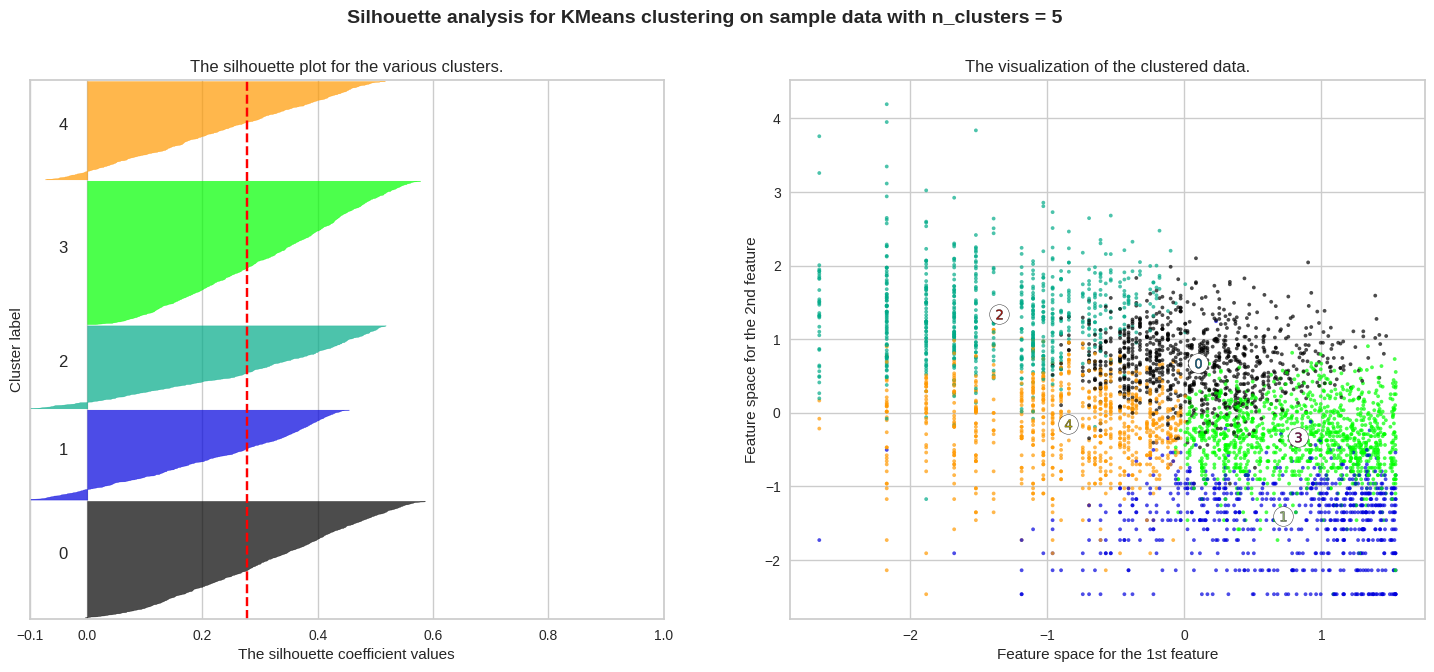

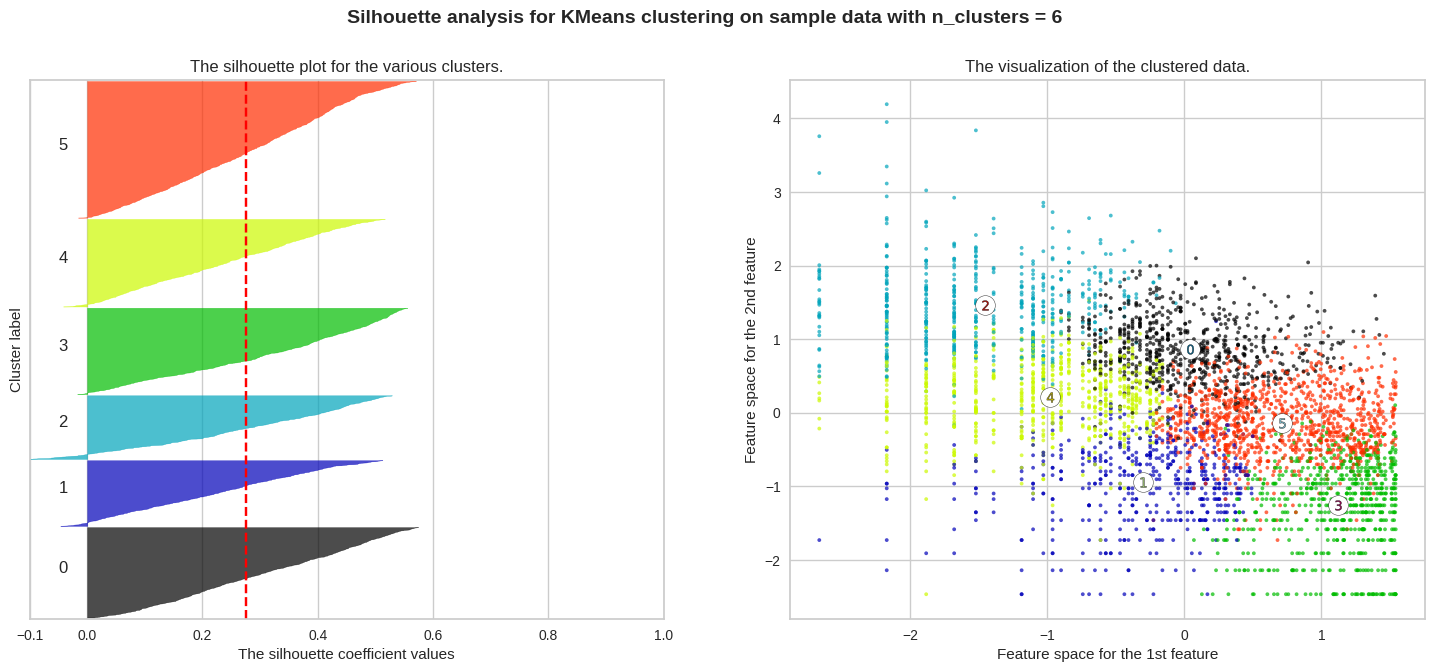

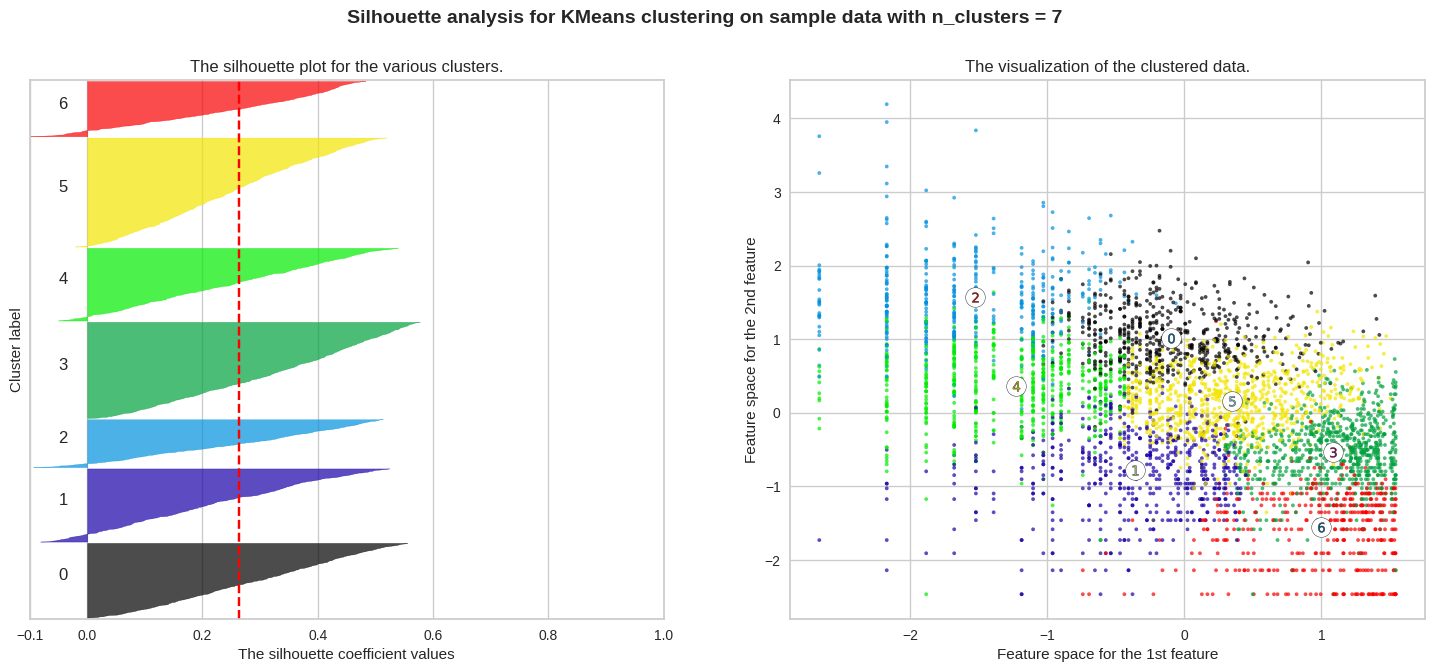

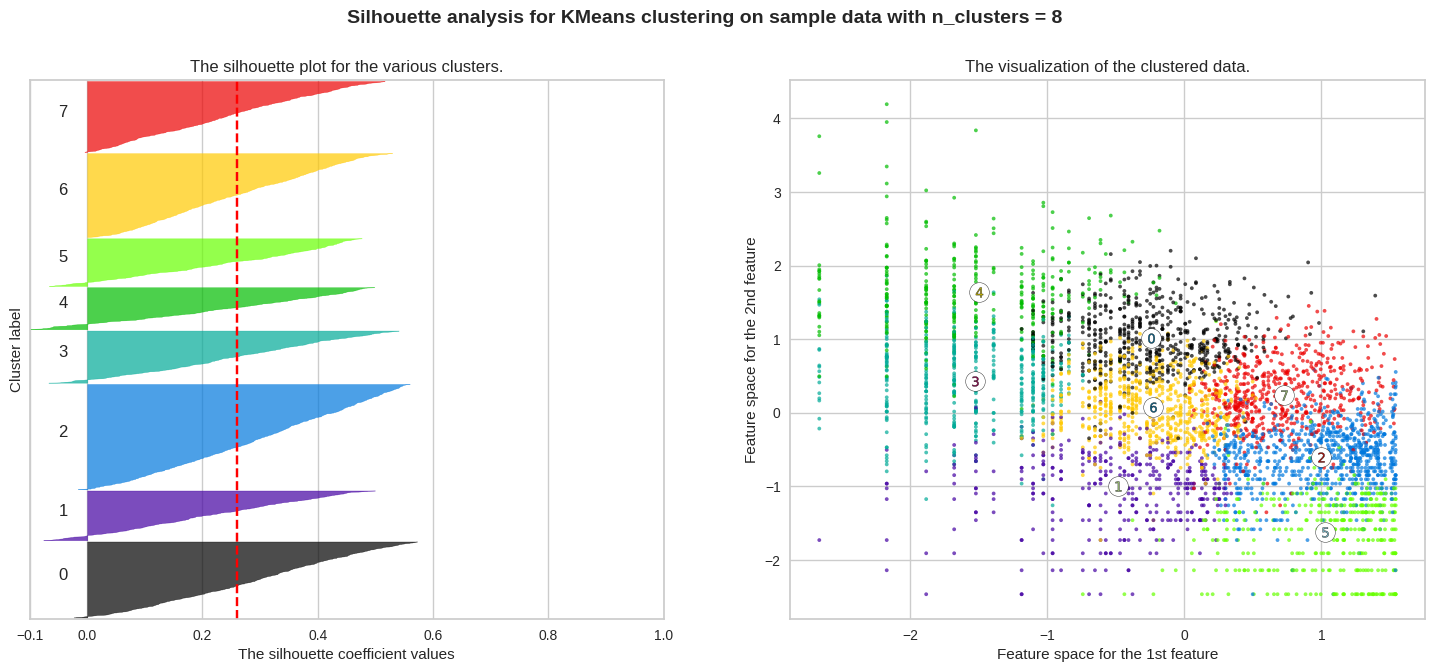

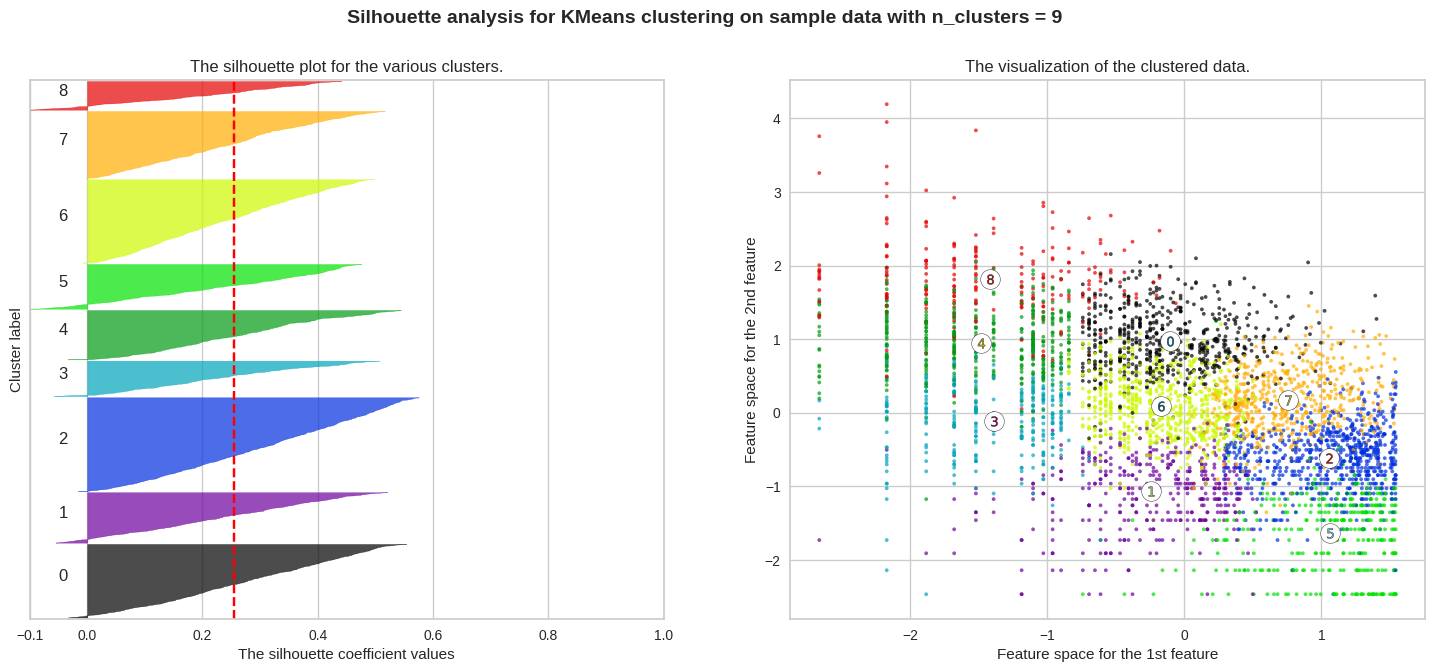

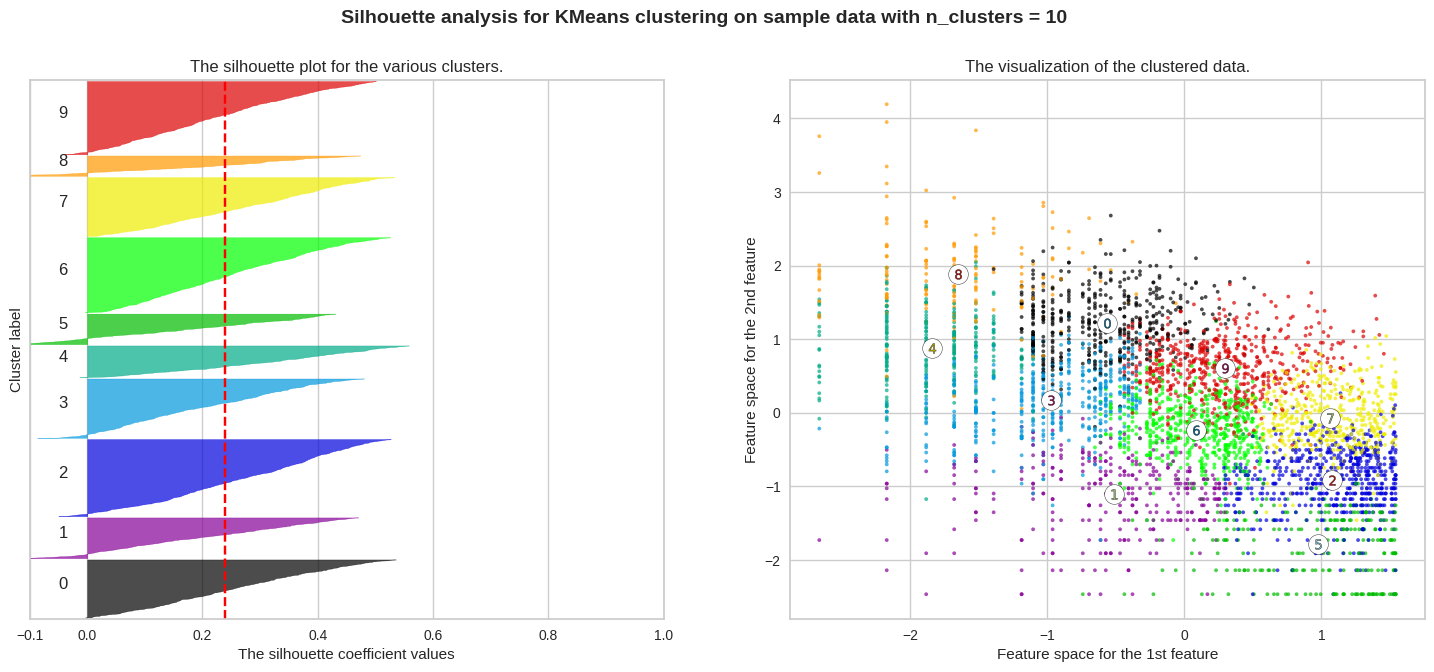

In [ ]:

from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

range_n_clusters = [2,3,4,5,6,7,8,9,10]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) /n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")
    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()


**So giving n_clusters=2 on Kmeans Model.**

In [ ]:
# applying Kmeans_clustering algorithm
kmeans_freq_mon_rec = KMeans(n_clusters=2)
kmeans_freq_mon_rec.fit(X)
y_kmeans= kmeans_freq_mon_rec.predict(X)

In [ ]:
#Find the clusters for the observation given in the dataset
rfm_dataframe['Cluster_based_on_freq_mon_rec'] = kmeans_freq_mon_rec.labels_
rfm_dataframe.head(10)

,Recency,Frequency,Monetary,Recency_log,Monetary_log,Cluster_based_rec_mon,Frequency_log,Cluster_based_on_freq_mon,Cluster_based_on_freq_mon_rec
CustomerID,,,,,,,,,
12346.0,325,2,0.00,5.786897,0.000000,0,1.098612,0,0
12347.0,2,182,4310.00,1.098612,8.368925,1,5.209486,1,1
12348.0,75,31,1797.24,4.330733,7.494564,1,3.465736,1,0
12349.0,18,73,1757.55,2.944439,7.472245,1,4.304065,1,1
12350.0,310,17,334.40,5.739793,5.815324,0,2.890372,0,0
12352.0,36,95,1545.41,3.610918,7.343691,1,4.564348,1,1
12353.0,204,4,89.00,5.323010,4.499810,0,1.609438,0,0
12354.0,232,58,1079.40,5.451038,6.985087,0,4.077537,1,0
12355.0,214,13,459.40,5.370638,6.132096,0,2.639057,0,0


In [ ]:
# Centers of the clusters(coordinates)
centers = kmeans_freq_mon_rec.cluster_centers_
centers

array([[ 0.55534174, -0.64793696, -0.62332763],
       [-0.71100128,  0.82955048,  0.79804328]])

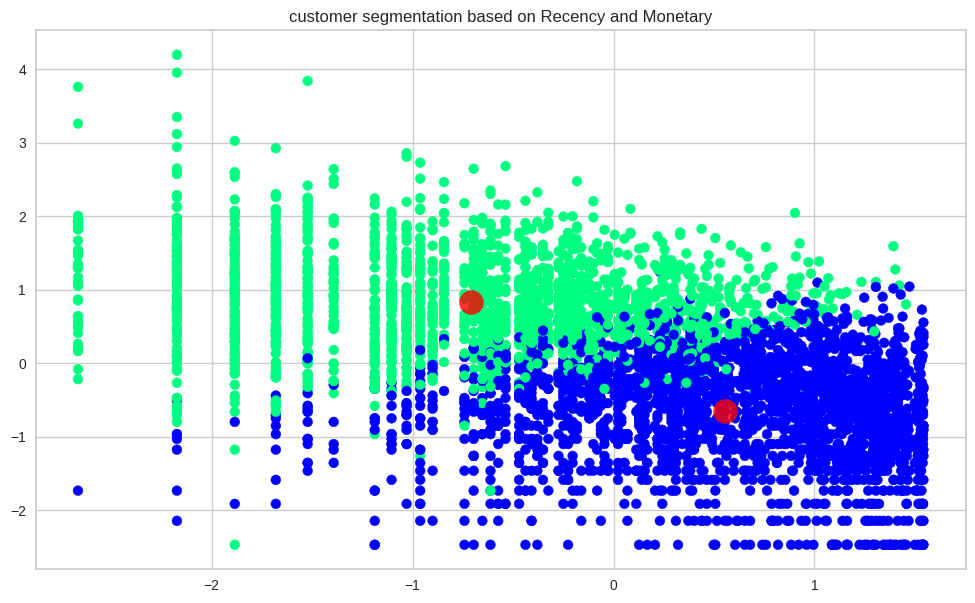

In [ ]:
# ploting visualizing the clusters
plt.figure(figsize=(12,7))
plt.title('customer segmentation based on Recency and Monetary')
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='winter')

centers = kmeans_freq_mon_rec.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=300, alpha=0.8)

In [ ]:
import scipy.cluster.hierarchy as sch

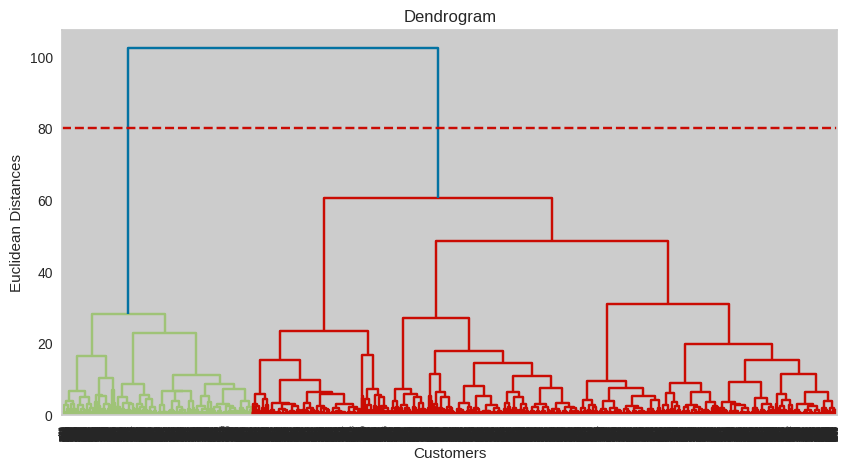

In [ ]:
plt.figure(figsize=(10,5))
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))

plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.axhline(y=80, color='r', linestyle='--')
plt.show() # find largest vertical distance we can make without crossing any other horizontal line

### <b> The number of clusters will be the number of vertical lines which are being intersected by the line drawn using the threshold. </b>

### No. of Cluster  = 2

In [ ]:
# Fitting hierarchical clustering to the mall dataset
from sklearn.cluster import AgglomerativeClustering
h_clustering = AgglomerativeClustering(n_clusters = 2, linkage = 'ward')
y_hc = h_clustering.fit_predict(X)

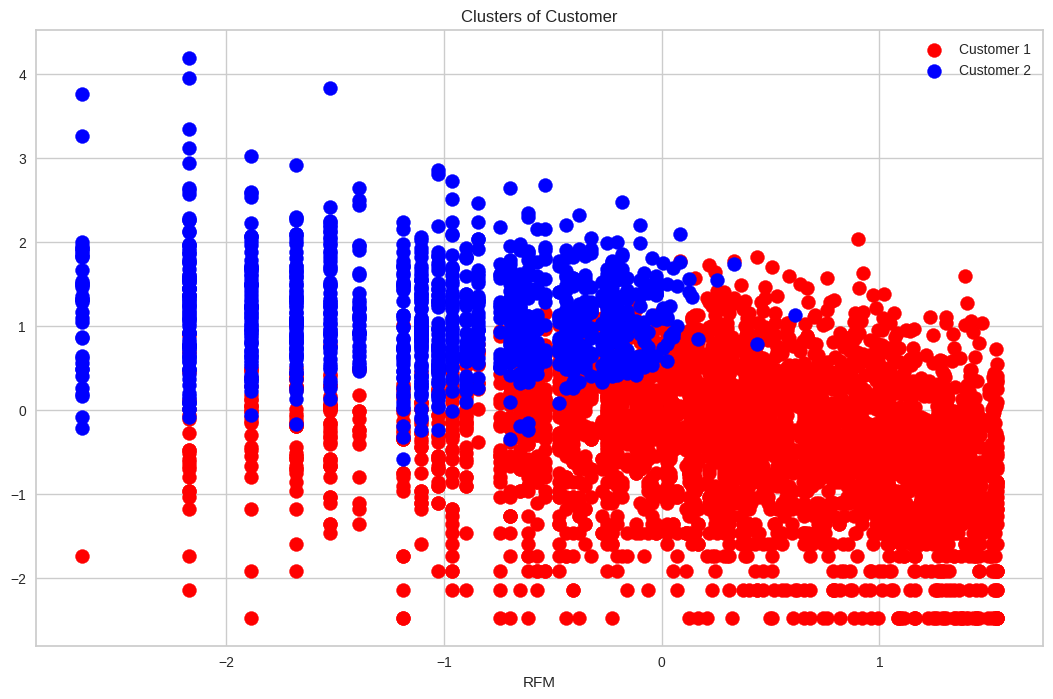

In [ ]:
# Visualizing the clusters (two dimensions only)
plt.figure(figsize=(13,8))
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Customer 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Customer 2')
#plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Target')

plt.title('Clusters of Customer')
plt.xlabel('RFM')

plt.legend()
plt.show()

In [ ]:
rfm_dataframe.head(1)

,Recency,Frequency,Monetary,Recency_log,Monetary_log,Cluster_based_rec_mon,Frequency_log,Cluster_based_on_freq_mon,Cluster_based_on_freq_mon_rec
CustomerID,,,,,,,,,
12346.0,325,2,0.0,5.786897,0.0,0,1.098612,0,0


In [ ]:
data_process_normalized=rfm_dataframe[['Recency','Frequency','Monetary','Recency_log','Frequency_log','Monetary_log','Cluster_based_on_freq_mon_rec']]

In [ ]:
data_process_normalized.groupby('Cluster_based_on_freq_mon_rec').agg({
    'Recency': ['mean', 'min', 'max'],
    'Frequency': ['mean', 'min', 'max'],
    'Monetary': ['mean', 'min', 'max','count']
})

Recency            Frequency            \
                                     mean min  max        mean min   max   
Cluster_based_on_freq_mon_rec                                              
0                              138.052871   0  373   25.619579   1   202   
1                               28.755113   0  330  180.672260   1  7983   

                                  Monetary                           
                                      mean     min        max count  
Cluster_based_on_freq_mon_rec                                        
0                               435.555990    0.00    4314.72  2421  
1                              3806.404773  161.03  279489.02  1907

# **Conclusion**

The Online Retail clustering project aimed to segment customers based on their purchasing behavior using data cleaning, exploratory data analysis, and KMeans clustering. After preprocessing the dataset by removing missing values, duplicates, and irrelevant columns, meaningful features were analyzed to understand customer trends. Clustering revealed distinct customer groups, such as high-value buyers, frequent low-spending customers, and return-prone shoppers. These insights help businesses target loyal customers, re-engage inactive ones, and improve marketing strategies. Overall, the project provided a data-driven approach to understand and categorize customer behavior for better decision-making in retail operations.